In [1]:
import os
import glob
import pandas as pd
from tqdm import tqdm
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.metrics import roc_auc_score
import copy
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip -q -o "/content/drive/MyDrive/capston/training.zip" -d /content/physionet

BASE = '/content/physionet'
DATA_DIR_A = f'{BASE}/training_setA/training_setA'
DATA_DIR_B = f'{BASE}/training_setB/training_setB'

In [4]:
files_A = sorted(glob.glob(os.path.join(DATA_DIR_A, '*.psv')))
files_B = sorted(glob.glob(os.path.join(DATA_DIR_B, '*.psv')))
all_files = files_A + files_B

print(f"Found {len(files_A):,} files in Set A.")
print(f"Found {len(files_B):,} files in Set B.")
print(f"Total files to merge: {len(all_files):,}")

Found 20,336 files in Set A.
Found 20,000 files in Set B.
Total files to merge: 40,336


In [5]:
df_list = []
current_patient_id = 1

for filepath in tqdm(all_files):
    temp_df = pd.read_csv(filepath, sep='|')
    temp_df.insert(0, 'Patient_ID', current_patient_id)

    df_list.append(temp_df)

    current_patient_id += 1

100%|██████████| 40336/40336 [01:38<00:00, 410.60it/s]


In [6]:
master_df = pd.concat(df_list, ignore_index=True)

output_filename = 'physionet_combined.csv'
master_df.to_csv(output_filename, index=False)

print(f"Master CSV saved as:  {output_filename}")
print(f"Total Rows:           {master_df.shape[0]:,}")
print(f"Total Columns:        {master_df.shape[1]}")
print(f"Total Unique IDs:     {master_df['Patient_ID'].nunique():,}")

Master CSV saved as:  physionet_combined.csv
Total Rows:           1,552,210
Total Columns:        42
Total Unique IDs:     40,336


In [7]:
master_df['set'] = np.where(master_df['Patient_ID'] <= 20336, 'A', 'B')

In [8]:
display(master_df.head())
display(master_df.tail())

,Patient_ID,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,set
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,A
1,1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,A
2,1,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,A
3,1,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,A
4,1,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,...,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,A


,Patient_ID,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,set
1552205,40336,80.0,96.0,NaN,115.0,87.0,65.0,15.0,NaN,NaN,...,NaN,NaN,62.0,0,NaN,NaN,0.0,31,0,B
1552206,40336,74.0,97.0,NaN,114.0,83.0,67.0,15.0,NaN,NaN,...,NaN,NaN,62.0,0,NaN,NaN,0.0,32,0,B
1552207,40336,78.0,98.0,NaN,110.0,83.0,69.0,15.0,NaN,NaN,...,NaN,NaN,62.0,0,NaN,NaN,0.0,33,0,B
1552208,40336,82.0,99.0,36.6,124.0,91.0,71.0,16.0,NaN,NaN,...,NaN,NaN,62.0,0,NaN,NaN,0.0,34,0,B
1552209,40336,80.0,97.0,NaN,121.0,97.0,73.0,15.0,NaN,NaN,...,NaN,NaN,62.0,0,NaN,NaN,0.0,35,0,B


In [9]:
master_df.columns

Index(['Patient_ID', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp',
       'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST',
       'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
       'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
       'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
       'HospAdmTime', 'ICULOS', 'SepsisLabel', 'set'],
      dtype='object')

In [10]:
from sklearn.model_selection import train_test_split, StratifiedGroupKFold

SEED = 42

# 환자 단위 테이블: set과 환자별 라벨(한 번이라도 1이면 1)
pt = (master_df.groupby('Patient_ID')
      .agg(set=('set', 'first'), sepsis=('SepsisLabel', 'max'))
      .reset_index())
pt['strata'] = pt['set'] + '_' + pt['sepsis'].astype(str)  # A_0, A_1, B_0, B_1

# 1) Test 15% 먼저 분리
dev_pt, test_pt = train_test_split(
    pt, test_size=0.15, stratify=pt['strata'], random_state=SEED)

from sklearn.model_selection import StratifiedKFold

dev_pt = dev_pt.reset_index(drop=True)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_map = {}
for k, (_, va_idx) in enumerate(skf.split(dev_pt, dev_pt['strata'])):
    fold_map.update(dict.fromkeys(dev_pt.loc[va_idx, 'Patient_ID'], k))

pt['split'] = np.where(pt['Patient_ID'].isin(dev_pt['Patient_ID']), 'dev', 'test')
pt['fold'] = pt['Patient_ID'].map(fold_map).fillna(-1).astype(int)
pt.to_csv('patient_split.csv', index=False)

In [11]:
# 환자 겹침 없음 확인
assert set(dev_pt.Patient_ID).isdisjoint(test_pt.Patient_ID)
# 분할별, fold별 환자 수와 패혈증 비율, set 구성
print(pt.groupby('split').agg(n=('Patient_ID', 'size'), sepsis=('sepsis', 'mean')))
print(pt[pt.fold >= 0].groupby('fold').agg(n=('Patient_ID', 'size'),
      sepsis=('sepsis', 'mean'), setA=('set', lambda s: (s == 'A').mean())))

           n    sepsis
split                 
dev    34285  0.072685
test    6051  0.072715
         n    sepsis      setA
fold                          
0     6857  0.072627  0.504156
1     6857  0.072627  0.504156
2     6857  0.072627  0.504156
3     6857  0.072772  0.504156
4     6857  0.072772  0.504156


1. setA 비율이 다섯 fold 모두 0.504156으로 똑같은 건 정상
층화를 set과 라벨을 묶은 4개 그룹(A_0, A_1, B_0, B_1)으로 했기 때문에, 각 그룹이 fold마다 거의 같은 수로 나뉜다.

fold	A_0	A_1	B_0	B_1
0~2	3153	304	3206	194
3	3152	305	3206	194
4	3153	304	3205	195
test	2782	269	2829	171

나눠떨어지지 않아서 생기는 1명 차이가 A_0와 A_1 사이에서 주고받는 식이라, A 환자 수는 모든 fold에서 3,457명으로 같음. 3,457 ÷ 6,857 = 0.504156이라 값이 똑같이 나오는 것.

2. 패혈증 비율이 두 가지 값(0.072627, 0.072772)만 나오는 것도 정상.
양성 환자 수가 498명이냐 499명이냐의 차이라서, 1명 차이로 비율이 0.0145%p만 달라진다

3. 전체 합계가 맞음

dev 양성: 498 × 3 + 499 × 2 = 2,492명이고, 2,492 ÷ 34,285 = 0.072685로 출력값과 같음
test 양성: 0.072715 × 6,051 = 440명.
합치면 2,932명으로, 전체 패혈증 환자 수와 정확히 일치

In [12]:
# ===== 분할 검증 =====
# 앞 셀에서 만든 pt (Patient_ID, set, sepsis, strata, split, fold)와 master_df를 사용

# 1) 환자 ID 겹침 없음 + 전체 환자 수 일치
dev_ids  = set(pt.loc[pt['split'] == 'dev',  'Patient_ID'])
test_ids = set(pt.loc[pt['split'] == 'test', 'Patient_ID'])
assert dev_ids.isdisjoint(test_ids), 'dev/test 환자 중복'
assert len(dev_ids) + len(test_ids) == master_df['Patient_ID'].nunique() == 40336
assert pt['Patient_ID'].is_unique, '한 환자가 두 행 이상(= 두 fold 이상)에 배정됨'
assert (pt.loc[pt['split'] == 'dev', 'fold'] >= 0).all()
assert (pt.loc[pt['split'] == 'test', 'fold'] == -1).all()
print('[OK] 환자 단위 분리 검증 통과')

# 2) fold별 층(strata) 인원 — setA 비율이 똑같이 나오는 이유 확인
print('\n[층별 환자 수] (fold -1 = test)')
print(pd.crosstab(pt['fold'], pt['strata']))

# 3) 양성 환자 수 합계 검증
pos_by_fold = pt.groupby('fold')['sepsis'].sum()
print('\n[fold별 양성 환자 수]')
print(pos_by_fold)
assert pos_by_fold.sum() == pt['sepsis'].sum() == 2932

# 4) 행 단위 균형: 행 수, 행 단위 양성 비율, 체류시간
row_df = master_df[['Patient_ID', 'SepsisLabel']].merge(
    pt[['Patient_ID', 'fold']], on='Patient_ID', how='left')
assert row_df['fold'].notna().all(), '분할에 배정되지 않은 행 존재'

los = master_df.groupby('Patient_ID').size().rename('los')
pt_los = pt.merge(los, left_on='Patient_ID', right_index=True)

row_summary = pd.concat([
    row_df.groupby('fold').agg(rows=('SepsisLabel', 'size'),
                               row_pos_rate=('SepsisLabel', 'mean')),
    pt_los.groupby('fold')['los'].agg(los_mean='mean', los_median='median'),
], axis=1)
row_summary['row_pos_rate'] = (row_summary['row_pos_rate'] * 100).round(2)
row_summary['los_mean'] = row_summary['los_mean'].round(1)
print('\n[행 단위 균형] (row_pos_rate 단위: %)')
print(row_summary)
assert row_summary['rows'].sum() == len(master_df) == 1552210

[OK] 환자 단위 분리 검증 통과

[층별 환자 수] (fold -1 = test)
strata   A_0  A_1   B_0  B_1
fold                        
-1      2782  269  2829  171
 0      3153  304  3206  194
 1      3153  304  3206  194
 2      3153  304  3206  194
 3      3152  305  3206  194
 4      3153  304  3205  195

[fold별 양성 환자 수]
fold
-1    440
 0    498
 1    498
 2    498
 3    499
 4    499
Name: sepsis, dtype: int64

[행 단위 균형] (row_pos_rate 단위: %)
        rows  row_pos_rate  los_mean  los_median
fold                                            
-1    233321          1.80      38.6        38.0
 0    260460          1.82      38.0        39.0
 1    262985          1.81      38.4        38.0
 2    262953          1.80      38.3        38.0
 3    265925          1.78      38.8        39.0
 4    266566          1.78      38.9        39.0


행 단위 양성 비율이 1.78~1.82% 범위 안에 있어서, 행 단위 AUPRC를 fold끼리 비교해도 기준선 차이는 무시해도 될 수준. 행 수는 fold마다 최대 2.3% 정도 차이가 나지만, 체류 시간 분포 차이에서 오는 자연스러운 정도이다.

In [13]:
# Part 1 EDA 설정
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

EDA_SCOPE = 'dev'
FIG_DIR = 'figures/eda'
os.makedirs(FIG_DIR, exist_ok=True)

eda_ids = pt.loc[pt['split'] == 'dev', 'Patient_ID'] if EDA_SCOPE == 'dev' else pt['Patient_ID']

eda_df = master_df[master_df['Patient_ID'].isin(eda_ids)].copy()
eda_pt = pt[pt['Patient_ID'].isin(eda_ids)].copy()

print(f'EDA 범위: {EDA_SCOPE} | 환자 {eda_pt.shape[0]:,}명 | 행 {eda_df.shape[0]:,}개')
print(eda_pt['set'].value_counts().sort_index().to_dict())

EDA 범위: dev | 환자 34,285명 | 행 1,318,889개
{'A': 17285, 'B': 17000}


[환자 단위 / 행 단위 패혈증 비율]
     patients  sepsis_patients  patient_rate_%  ci95_low_%  ci95_high_%  \
set                                                                       
A       17285             1521            8.80        8.39         9.23   
B       17000              971            5.71        5.37         6.07   

       rows  row_pos_rate_%  
set                          
A    671312            2.17  
B    647577            1.42  

chi2 = 120.8, p = 4.27e-28, 위험비(A/B) = 1.54, Cramér's V = 0.059

[라벨 onset 시점 (ICULOS 기준, 패혈증 환자만)]
     sepsis_patients  onset_median  onset_q25  onset_q75  onset_le6h_pct  \
set                                                                        
A               1521          28.0        8.0       73.0            22.0   
B                971          28.0        5.0       73.0            28.2   

     onset_le24h_pct  pos_at_first_row_pct  
set                                         
A               47.3                  11.8  
B               

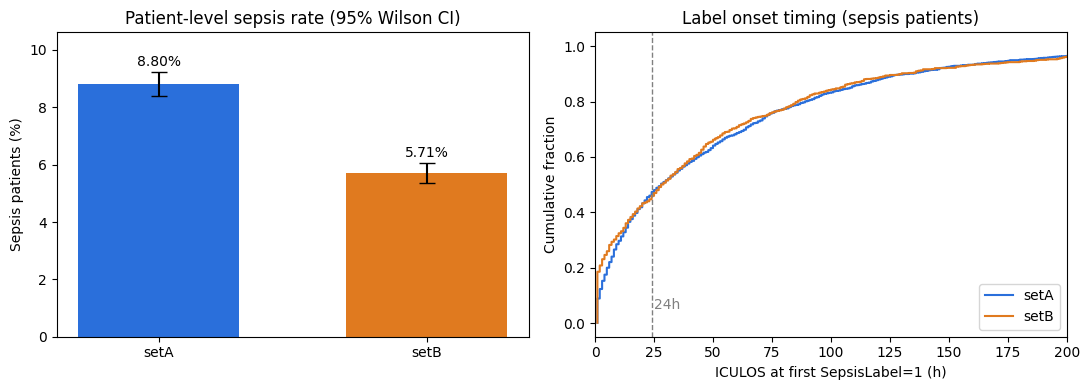

In [14]:
# 1. 패혈증 라벨 비교
from statsmodels.stats.proportion import proportion_confint


def label_summary(df_rows: pd.DataFrame, df_pt: pd.DataFrame) -> pd.DataFrame:
    """Return patient-level and row-level sepsis rates by set with 95% Wilson CI."""
    out = []
    for s, g in df_pt.groupby('set'):
        n, k = len(g), int(g['sepsis'].sum())
        lo, hi = proportion_confint(k, n, method='wilson')
        rows = df_rows[df_rows['set'] == s]['SepsisLabel']
        out.append({'set': s, 'patients': n, 'sepsis_patients': k,
                    'patient_rate_%': 100 * k / n,
                    'ci95_low_%': 100 * lo, 'ci95_high_%': 100 * hi,
                    'rows': len(rows), 'row_pos_rate_%': 100 * rows.mean()})
    return pd.DataFrame(out).set_index('set').round(2)


summary = label_summary(eda_df, eda_pt)
print('[환자 단위 / 행 단위 패혈증 비율]')
print(summary)

# 카이제곱 검정 + 효과 크기
ct = pd.crosstab(eda_pt['set'], eda_pt['sepsis'])
chi2, p, _, _ = stats.chi2_contingency(ct)
rr = summary.loc['A', 'patient_rate_%'] / summary.loc['B', 'patient_rate_%']
cramers_v = np.sqrt(chi2 / ct.values.sum())
print(f'\nchi2 = {chi2:.1f}, p = {p:.2e}, 위험비(A/B) = {rr:.2f}, Cramér\'s V = {cramers_v:.3f}')

# 첫 양성 시점(라벨 onset) 분포
first_row = eda_df.groupby('Patient_ID').first()
onset = (eda_df[eda_df['SepsisLabel'] == 1]
         .groupby('Patient_ID')
         .agg(set=('set', 'first'), onset_iculos=('ICULOS', 'min')))
onset['pos_at_first_row'] = onset.index.map(first_row['SepsisLabel']).astype(bool)

onset_tbl = onset.groupby('set').agg(
    sepsis_patients=('onset_iculos', 'size'),
    onset_median=('onset_iculos', 'median'),
    onset_q25=('onset_iculos', lambda x: x.quantile(0.25)),
    onset_q75=('onset_iculos', lambda x: x.quantile(0.75)),
    onset_le6h_pct=('onset_iculos', lambda x: 100 * (x <= 6).mean()),
    onset_le24h_pct=('onset_iculos', lambda x: 100 * (x <= 24).mean()),
    pos_at_first_row_pct=('pos_at_first_row', lambda x: 100 * x.mean()),
).round(1)
print('\n[라벨 onset 시점 (ICULOS 기준, 패혈증 환자만)]')
print(onset_tbl)

# 기록 시작 시점: 첫 행이 ICULOS=1인 환자 비율
start_tbl = first_row.groupby('set')['ICULOS'].agg(
    starts_at_1_pct=lambda x: 100 * (x == 1).mean(),
    first_iculos_median='median').round(1)
print('\n[기록 시작 시점]')
print(start_tbl)

ks = stats.ks_2samp(onset.loc[onset['set'] == 'A', 'onset_iculos'],
                    onset.loc[onset['set'] == 'B', 'onset_iculos'])
print(f'\nonset 분포 KS = {ks.statistic:.3f}, p = {ks.pvalue:.2e}')

# 그래프 : (왼쪽) 환자 단위 비율 + 95% CI, (오른쪽) onset ICULOS ECDF
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = {'A': '#2a6fdb', 'B': '#e07a1f'}

ax = axes[0]
for i, s in enumerate(summary.index):
    r = summary.loc[s]
    ax.bar(i, r['patient_rate_%'], color=colors[s], width=0.6)
    ax.errorbar(i, r['patient_rate_%'],
                yerr=[[r['patient_rate_%'] - r['ci95_low_%']], [r['ci95_high_%'] - r['patient_rate_%']]],
                color='black', capsize=6)
    ax.text(i, r['ci95_high_%'] + 0.2, f"{r['patient_rate_%']:.2f}%", ha='center')
ax.set_xticks(range(len(summary.index)), [f'set{s}' for s in summary.index])
ax.set_ylim(0, summary['ci95_high_%'].max() * 1.15)
ax.set_ylabel('Sepsis patients (%)')
ax.set_title('Patient-level sepsis rate (95% Wilson CI)')

ax = axes[1]
for s, g in onset.groupby('set'):
    x = np.sort(g['onset_iculos'].values)
    ax.step(x, np.arange(1, len(x) + 1) / len(x), where='post', color=colors[s], label=f'set{s}')
ax.axvline(24, color='gray', ls='--', lw=1)
ax.text(25, 0.05, '24h', color='gray')
ax.set_xlim(0, 200)
ax.set_xlabel('ICULOS at first SepsisLabel=1 (h)')
ax.set_ylabel('Cumulative fraction')
ax.set_title('Label onset timing (sepsis patients)')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p1_label_rate_onset.png', dpi=150)
plt.show()

특정 시점이나 기간에 어떤 질병을 가지고 있는 사람의 수를 전체 인구수로 나눈 비율인 유병률 차이는 실질적인 차이로 보인다. 95% 신뢰구간이 겹치지 않고, A가 B보다 1.54배 높다. Cramér’s V가 0.059로 작게 나오는 건 두 세트 모두 기저 유병률이 낮아서 생기는 효과. 그래서 리포트를 작성함에 있어서는 위험비와 절대 차이(3.1%p)로 해석하는 게 옳다.
onset 시점 분포는 거의 같아요. 중앙값과 Q3가 같고, KS도 0.097로 작음. 그림에서도 두 곡선이 거의 겹침. 차이는 초반에만 존재. B는 첫 행부터 양성인 환자가 더 많아서(19.2% 대 11.8%) 곡선 앞부분이 조금 더 높다.

이 결과가 모델링에 주는 의미:
첫 행부터 양성인 환자는 6시간 전에 예측할 과거 데이터가 아예 없다. 이런 환자를 학습과 평가에서 어떻게 다룰지 Part 2에서 정해본다.
A는 기록이 체류 중간부터 시작하는 환자가 36.6%. 그래서 이 환자들은 ICULOS가 1이 아니라 중간값부터 시작. Part 2에서 ICULOS를 지름길 변수로 볼 때 이 점을 같이 고려해야 한다.
유병률 차이는 이미 층화 분할로 대응. 그래서 결론에서는 "분할 단계에서 처리 완료"로 정리.

[결측률 (%)]  row_miss: 행 단위 결측률, never: 체류 중 한 번도 측정되지 않은 환자 비율
                  row_miss_A  row_miss_B  never_A  never_B  row_diff(B-A)  \
DBP                     48.0        13.9     36.2      0.1          -34.1   
Unit1                   49.1        29.5     47.0     30.4          -19.6   
Unit2                   49.1        29.5     47.0     30.4          -19.6   
FiO2                    85.7        97.7     40.9     70.8           12.0   
Resp                     9.8        21.0      0.1      0.2           11.2   
BaseExcess              89.5        99.8     37.6     97.1           10.3   
Glucose                 87.8        77.8      2.0      5.7          -10.0   
pH                      88.4        97.8     35.0     71.1            9.3   
HCO3                    91.9        99.8      2.6     97.9            7.9   
Chloride                91.7        99.4      2.6     91.9            7.7   
EtCO2                  100.0        92.6    100.0     83.9           -7.4   
PaCO2         

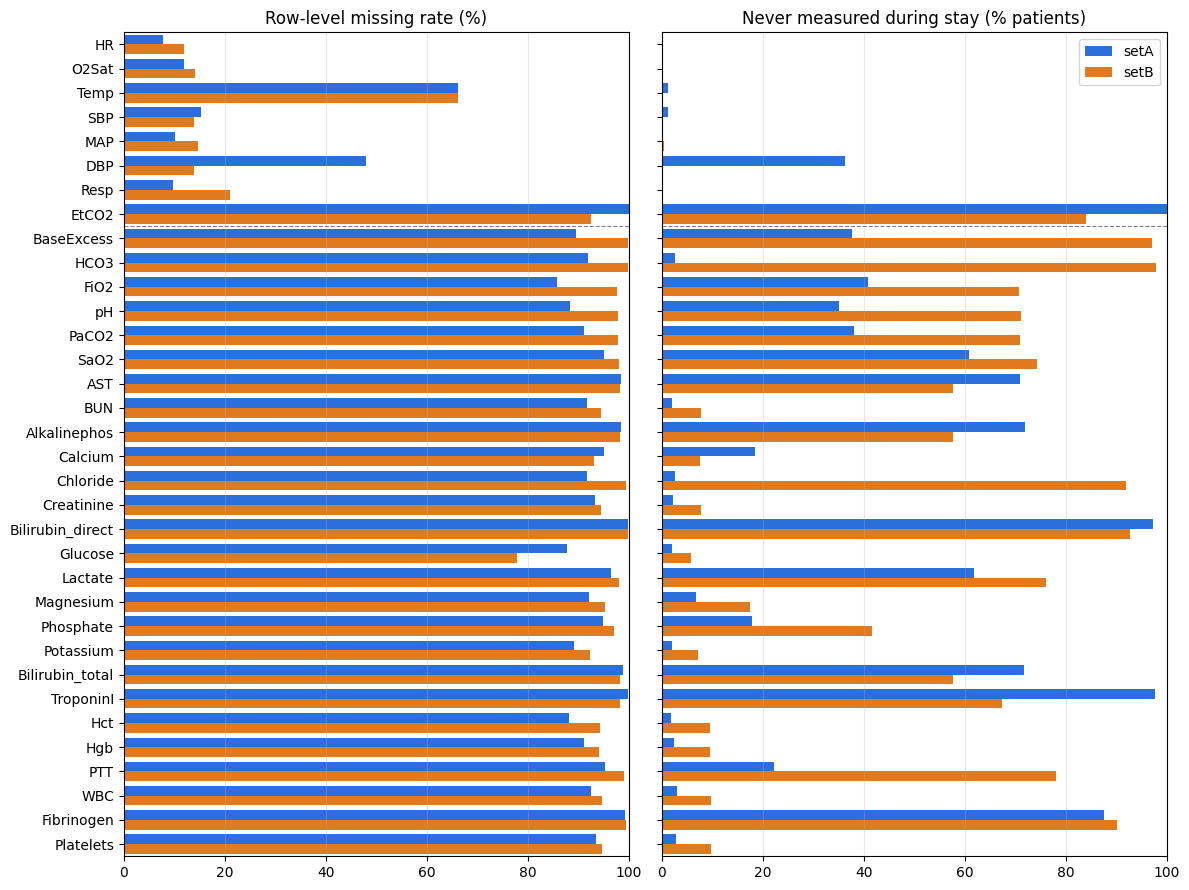


Unit1·Unit2 결측 불일치 행 수: 0
[Unit별 환자 수 / 패혈증 비율(%)]
             patients  sepsis_pct
set unit                         
A   MICU         4530        10.6
    SICU         4633         4.2
    Unknown      8122        10.4
B   MICU         5891         5.6
    SICU         5945         6.3
    Unknown      5164         5.2


In [15]:
# 변수별 결측률 비교 (setA vs setB)
VITALS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']
LABS = ['BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN',
        'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct',
        'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium',
        'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
        'Fibrinogen', 'Platelets']
DEMO = ['Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime']
CLINICAL = VITALS + LABS


def missing_table(df_rows: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Row-level missing % and patient-level never-measured % by set."""
    row_miss = df_rows.groupby('set')[cols].apply(lambda g: g.isna().mean() * 100).T
    never = (df_rows.groupby(['set', 'Patient_ID'])[cols]
             .apply(lambda g: g.notna().any())
             .groupby('set').mean().T)
    never = (1 - never) * 100
    tbl = pd.DataFrame({
        'row_miss_A': row_miss['A'], 'row_miss_B': row_miss['B'],
        'never_A': never['A'], 'never_B': never['B'],
    })
    tbl['row_diff(B-A)'] = tbl['row_miss_B'] - tbl['row_miss_A']
    tbl['never_diff(B-A)'] = tbl['never_B'] - tbl['never_A']
    tbl['group'] = ['vital' if c in VITALS else 'lab' if c in LABS else 'demo' for c in tbl.index]
    return tbl.round(1)


miss_tbl = missing_table(eda_df, CLINICAL + DEMO)
print('[결측률 (%)]  row_miss: 행 단위 결측률, never: 체류 중 한 번도 측정되지 않은 환자 비율')
print(miss_tbl.sort_values('row_diff(B-A)', key=abs, ascending=False))

# 차이가 큰 변수: 행 단위 또는 환자 단위에서 |차이| >= 10%p
big = miss_tbl[(miss_tbl['row_diff(B-A)'].abs() >= 10) | (miss_tbl['never_diff(B-A)'].abs() >= 10)]
print(f'\n[|차이| >= 10%p 변수: {len(big)}개]')
print(big[['row_miss_A', 'row_miss_B', 'never_A', 'never_B']])

# 그래프는 임상 변수 34개, 행 단위(왼쪽) / 환자 단위(오른쪽) 결측률을 A·B 나란히
plot_tbl = miss_tbl.loc[CLINICAL]
fig, axes = plt.subplots(1, 2, figsize=(12, 9), sharey=True)
y = np.arange(len(plot_tbl))
for ax, (a, b, title) in zip(axes, [('row_miss_A', 'row_miss_B', 'Row-level missing rate (%)'),
                                     ('never_A', 'never_B', 'Never measured during stay (% patients)')]):
    ax.barh(y - 0.2, plot_tbl[a], height=0.4, color=colors['A'], label='setA')
    ax.barh(y + 0.2, plot_tbl[b], height=0.4, color=colors['B'], label='setB')
    ax.set_xlim(0, 100)
    ax.set_title(title)
    ax.axhline(len(VITALS) - 0.5, color='gray', lw=0.8, ls='--')
    ax.grid(axis='x', alpha=0.3)
axes[0].set_yticks(y, plot_tbl.index)
axes[0].set_ylim(len(plot_tbl) - 0.5, -0.5)   # 위에서부터 vitals → labs
axes[1].legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p1_missing_rate.png', dpi=150)
plt.show()

# Unit 결측 패턴: Unit1/Unit2가 항상 같이 결측인지, 결측일 때 패혈증 비율
unit_pt = eda_df.groupby('Patient_ID').agg(set=('set', 'first'), u1=('Unit1', 'first'),
                                           u2=('Unit2', 'first'), y=('SepsisLabel', 'max'))
print('\nUnit1·Unit2 결측 불일치 행 수:', int((eda_df['Unit1'].isna() != eda_df['Unit2'].isna()).sum()))
unit_pt['unit'] = np.select([unit_pt['u1'] == 1, unit_pt['u2'] == 1], ['MICU', 'SICU'], 'Unknown')
print('[Unit별 환자 수 / 패혈증 비율(%)]')
print(unit_pt.groupby(['set', 'unit'])['y'].agg(patients='size', sepsis_pct=lambda x: round(100 * x.mean(), 1)))

1. 결측이 환자 상태가 아니라 병원 시스템 때문에 생기는 경우가 있음. 이번 단계에서 가장 중요한 발견

HCO3와 Chloride는 A에서는 거의 모든 환자가 측정됐는데, B에서는 92~98% 환자가 한 번도 측정되지 않았다.
DBP는 그 반대. A 환자 36%가 체류 내내 기록이 x.
이런 차이는 환자가 아파서 생긴 게 아니라, 그 병원 EMR이 해당 항목을 기록하지 않는 것으로 보는 것이 적합하다.

모델링에 주는 의미: 이런 변수의 측정 여부 indicator를 피처로 넣으면, 모델은 "어느 병원 데이터인지"를 알아내는 신호로 쓰게 된다. 그래서 이 변수들은 indicator 대상에서 빼거나, A에서 학습하고 B에서 평가하는 실험으로 영향을 확인해보아야 한다.

2. 행 단위 결측률만 보면 이 차이를 놓침.
HCO3는 행 단위로 보면 91.9%와 99.8%라 차이가 7.9%p에 불과, 그런데 환자 단위로 보면 95%p나 차이가 존재. 처음에 "분석 단위는 행과 환자를 둘 다 본다"는 원칙을 세운 이유를 엿볼 수 있다.

3. SOFA 계산에 쓰는 변수는 상대적으로 양호하다.
Platelets와 Creatinine은 한 번도 측정되지 않은 환자가 A 2~3%, B 8~10% 수준. Bilirubin_total은 A 71.7%, B 57.6%로 오히려 A가 더 부족. 이 차이는 SOFA 간 항목의 측정 전 비율에 그대로 반영될 것으로 보인다.

[환자별 시간당 측정률 / 측정 간격(시간)]  값: 중앙값 [Q1, Q3], 측정 이력이 있는 환자만
                            rate_A             rate_B  rate_KS  \
var                                                              
HR               0.95 [0.89, 0.98]  0.93 [0.86, 0.96]    0.218   
O2Sat            0.93 [0.83, 0.97]  0.92 [0.83, 0.95]    0.152   
SBP              0.92 [0.81, 0.97]  0.91 [0.83, 0.95]    0.142   
MAP              0.93 [0.85, 0.98]  0.91 [0.83, 0.95]    0.182   
DBP              0.88 [0.67, 0.97]  0.91 [0.83, 0.95]    0.182   
Resp             0.94 [0.87, 0.98]  0.85 [0.71, 0.92]    0.351   
Temp             0.26 [0.22, 0.35]  0.24 [0.21, 0.32]    0.102   
WBC              0.06 [0.05, 0.10]  0.05 [0.04, 0.07]    0.203   
Platelets        0.06 [0.05, 0.08]  0.05 [0.04, 0.07]    0.132   
Creatinine       0.06 [0.05, 0.08]  0.05 [0.04, 0.07]    0.146   
BUN              0.07 [0.05, 0.11]  0.05 [0.04, 0.07]    0.247   
Glucose          0.09 [0.05, 0.16]  0.20 [0.09, 0.29]    0.379   
Hgb              0

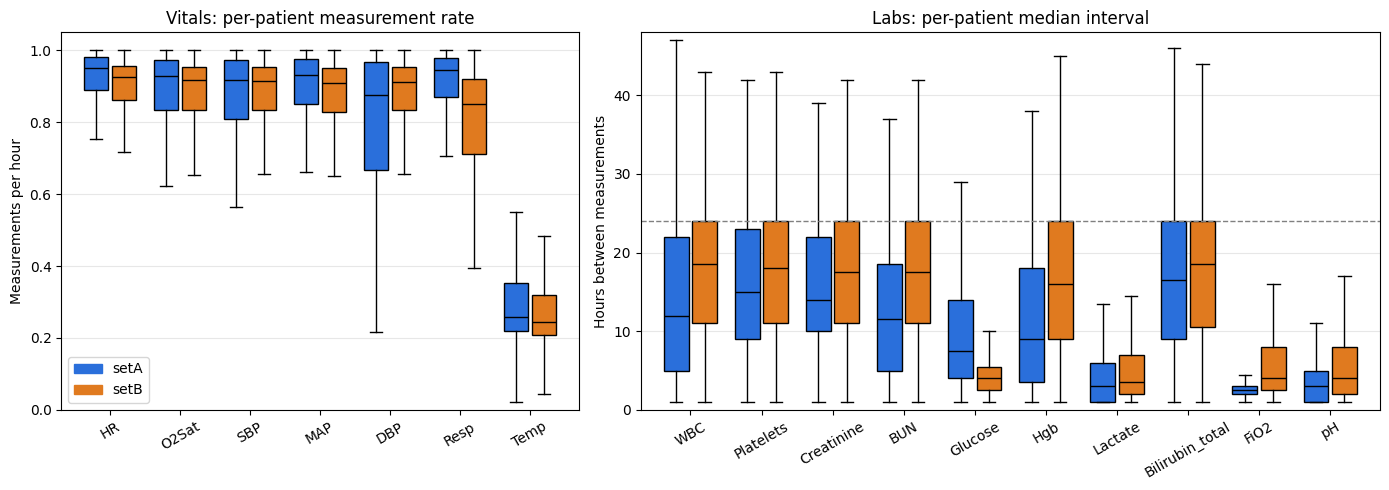

In [16]:
# 측정 빈도 분포 비교 (setA vs setB)
FREQ_VARS = ['HR', 'O2Sat', 'SBP', 'MAP', 'DBP', 'Resp', 'Temp',              # 활력징후
             'WBC', 'Platelets', 'Creatinine', 'BUN', 'Glucose', 'Hgb',        # 정기 검사
             'Lactate', 'Bilirubin_total', 'FiO2', 'pH']                       # 선택적 검사

# (1) 환자별 시간당 측정률 = 측정 횟수 / 체류 시간(행 수)
#  한 번도 측정되지 않은 환자는 ①에서 다뤘으므로 제외 → "측정하는 환자에서 얼마나 자주"를 비교
g = eda_df.groupby('Patient_ID')
counts = g[FREQ_VARS].count()
los = g.size()
rate = counts.div(los, axis=0).where(counts > 0)          # 0회 측정 환자는 NaN
rate['set'] = g['set'].first()

# (2) 측정 간격(시간): 같은 환자 안에서 연속된 두 측정 사이 ICULOS 차이
def interval_by_patient(df_rows: pd.DataFrame, var: str) -> pd.Series:
    """Median hours between consecutive measurements of `var`, per patient."""
    m = df_rows.loc[df_rows[var].notna(), ['Patient_ID', 'ICULOS']]
    gap = m.groupby('Patient_ID')['ICULOS'].diff()
    return gap.groupby(m['Patient_ID']).median()

interval = pd.DataFrame({v: interval_by_patient(eda_df, v) for v in FREQ_VARS})
interval['set'] = g['set'].first()

# (3) 요약표: 중앙값 [Q1, Q3] + KS 통계량
def iqr_str(x: pd.Series, fmt: str) -> str:
    """Format median [Q1, Q3]."""
    x = x.dropna()
    return f'{x.median():{fmt}} [{x.quantile(.25):{fmt}}, {x.quantile(.75):{fmt}}]'

rows = []
for v in FREQ_VARS:
    ra, rb = rate.loc[rate['set'] == 'A', v].dropna(), rate.loc[rate['set'] == 'B', v].dropna()
    ia, ib = interval.loc[interval['set'] == 'A', v].dropna(), interval.loc[interval['set'] == 'B', v].dropna()
    rows.append({
        'var': v,
        'rate_A': iqr_str(ra, '.2f'), 'rate_B': iqr_str(rb, '.2f'),
        'rate_KS': stats.ks_2samp(ra, rb).statistic,
        'interval_h_A': iqr_str(ia, '.1f'), 'interval_h_B': iqr_str(ib, '.1f'),
        'interval_KS': stats.ks_2samp(ia, ib).statistic if len(ia) and len(ib) else np.nan,
    })
freq_tbl = pd.DataFrame(rows).set_index('var').round(3)
print('[환자별 시간당 측정률 / 측정 간격(시간)]  값: 중앙값 [Q1, Q3], 측정 이력이 있는 환자만')
print(freq_tbl)
print('\n[KS >= 0.2 (분포 차이 큼)]')
print(freq_tbl[(freq_tbl['rate_KS'] >= 0.2) | (freq_tbl['interval_KS'] >= 0.2)][['rate_KS', 'interval_KS']])

# (4) 그래프: 측정률 박스플롯(왼쪽, 활력징후) / 측정 간격 박스플롯(오른쪽, 검사값)
VIT_SHOW = ['HR', 'O2Sat', 'SBP', 'MAP', 'DBP', 'Resp', 'Temp']
LAB_SHOW = ['WBC', 'Platelets', 'Creatinine', 'BUN', 'Glucose', 'Hgb', 'Lactate', 'Bilirubin_total', 'FiO2', 'pH']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [7, 10]})
for ax, (data, cols, ylab, title, ylim) in zip(axes, [
        (rate, VIT_SHOW, 'Measurements per hour', 'Vitals: per-patient measurement rate', (0, 1.05)),
        (interval, LAB_SHOW, 'Hours between measurements', 'Labs: per-patient median interval', (0, 48))]):
    pos = np.arange(len(cols))
    for off, s in [(-0.2, 'A'), (0.2, 'B')]:
        vals = [data.loc[data['set'] == s, c].dropna().values for c in cols]
        bp = ax.boxplot(vals, positions=pos + off, widths=0.35, patch_artist=True,
                        showfliers=False, medianprops={'color': 'black'})
        for b in bp['boxes']:
            b.set_facecolor(colors[s])
    ax.set_xticks(pos, cols, rotation=30)
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
axes[1].axhline(24, color='gray', ls='--', lw=1)
axes[0].legend([plt.Rectangle((0, 0), 1, 1, color=colors[s]) for s in 'AB'], ['setA', 'setB'], loc='lower left')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p1_measurement_freq.png', dpi=150)
plt.show()

1. 측정 빈도도 병원 시스템의 특징이다.
결측 여부가 병원마다 달랐던 것처럼, 빈도도 병원마다 다를 것이다. A는 혈액검사와 혈액가스를 자주 하고, B는 혈당을 자주 기록한다. B의 혈당은 침상 옆에서 바로 재는 간이 검사까지 기록됐을 가능성이 있다고 생각해볼 수 있다. 이 차이는 환자 상태보다는 병원의 진료 관행을 반영한다고 보자.

2. 특징 설계에 바로 영향을 준다. 이번 단계에서 가장 중요한 결과

window 통계가 계산되지 않는 경우가 생긴다. 24시간 window 안에 B의 일반 검사는 대부분 측정값이 1개뿐(간격 17~18h). 값이 1개면 표준편차, 기울기, 변화율을 계산할 수 없다. 그래서 이런 통계는 측정값이 2개 이상일 때만 계산하고, 아니면 NaN으로 두는 규칙이 필요할 것으로 보인다.
"마지막 측정 이후 경과 시간" 특징의 의미가 병원마다 달라진다. 같은 “WBC가 15시간 전 측정”이어도 A에서는 늦은 편이고 B에서는 보통임. 그대로 쓰면 모델이 병원 차이를 학습할 수 있다.
측정 횟수를 특징으로 쓰면 병원을 구분하는 신호가 된다. FiO2와 pH 측정 횟수가 특히 그렇다. 앞에서 미리 확인했을 때 FiO2 누적 측정 횟수의 AUROC가 0.673으로 높았는데, 그중 일부는 “A 병원이면 측정이 많고 유병률도 높다”는 혼동 효과일 수 있다. 이건 Part 2에서 set을 나눠서 다시 확인한다.

3. Forward Fill 근거로도 쓸 수 있다.
활력징후는 거의 매시간 측정돼서 Forward Fill로 채워도 길어야 1~2시간 전 값. 반면 검사값은 최대 24시간 전 값을 끌어오게 된다. 그래서 검사값에는 Forward Fill에 상한을 둘지(예: 24시간이 지난 값은 다시 결측 처리) 결정해야 한다. 측정 간격 박스의 Q3가 24시간에 걸쳐 있다는 게 그 근거이다.

[분포 비교]  SMD: (A-B)/pooled SD, |SMD|>=0.2 의미 있는 차이 / KS: 분포 모양 차이
                 row_med_A  row_med_B  row_SMD  row_KS  pt_SMD  pt_KS  \
MAP                  77.00      84.00   -0.494   0.198  -0.689  0.271   
DBP                  58.00      65.00   -0.481   0.196  -0.626  0.254   
SBP                 118.00     124.00   -0.250   0.107  -0.350  0.154   
WBC                  10.80       9.60    0.228   0.115   0.292  0.140   
Temp                 37.06      36.90    0.139   0.104   0.291  0.177   
FiO2                  0.50       0.40    0.060   0.152   0.191  0.214   
Bilirubin_total       0.90       0.80    0.228   0.113   0.168  0.111   
Creatinine            0.90       0.99   -0.128   0.120  -0.160  0.116   
Age                  65.23      63.00    0.119   0.093   0.117  0.089   
Lactate               1.80       1.97   -0.201   0.079  -0.113  0.064   
HR                   84.00      83.00    0.053   0.034   0.110  0.062   
Platelets           181.00     180.00    0.066   0.022   0

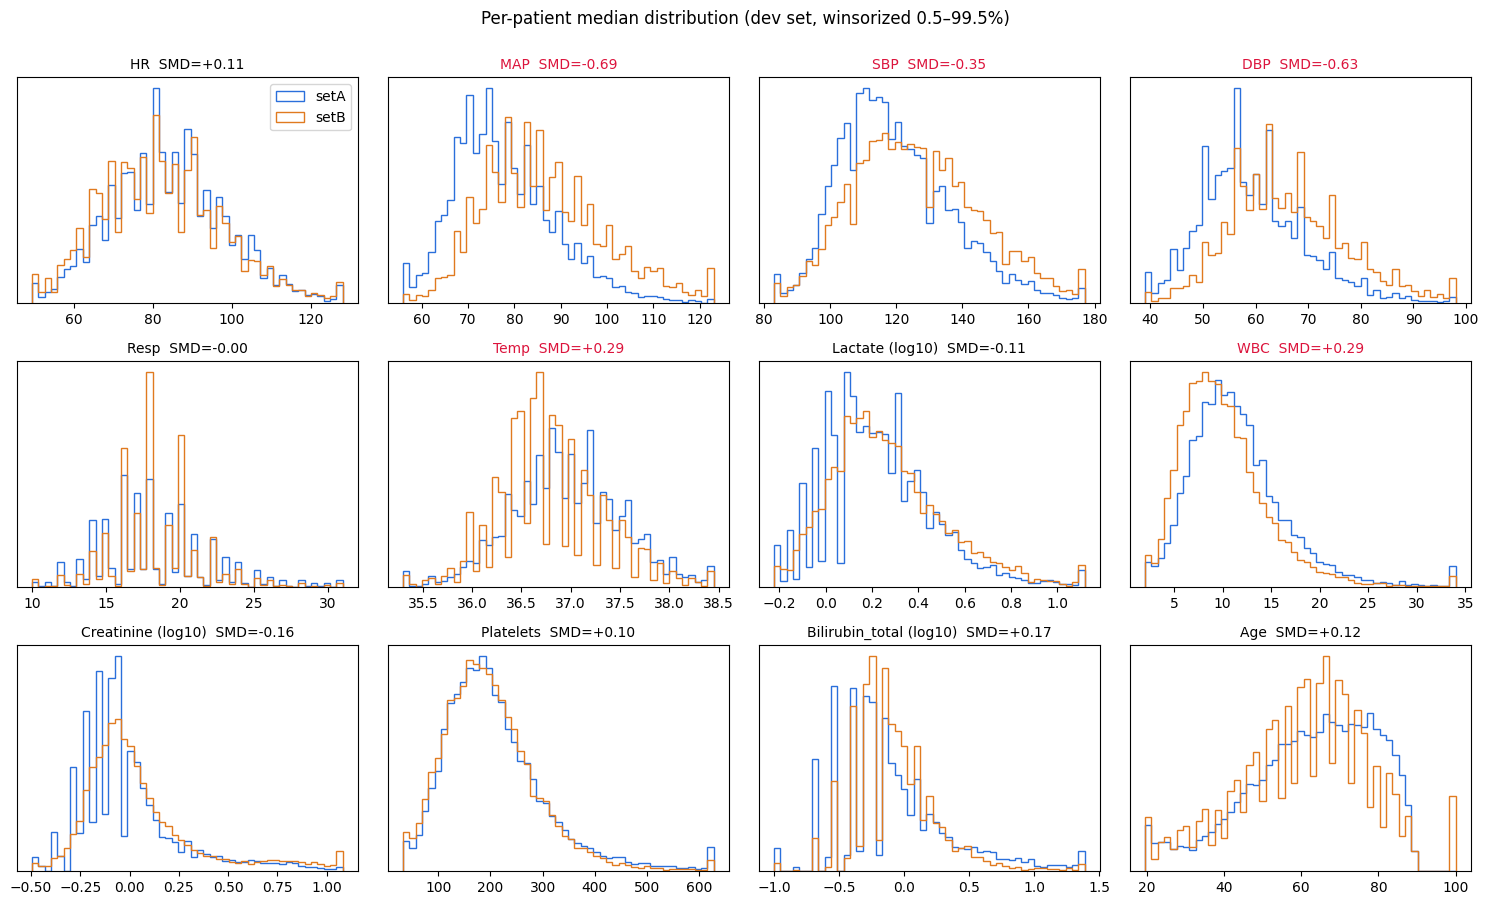


[기준 충족 행 비율(%)] (측정된 행 기준)
     MAP<70 (SOFA 심혈관 1점)  SBP<=100 (qSOFA)
set                                        
A                    28.5              17.0
B                    14.0              13.7


In [17]:
# 주요 변수 분포 비교 (setA vs setB)
DIST_VARS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp',
             'Lactate', 'WBC', 'Platelets', 'Creatinine', 'BUN', 'Bilirubin_total',
             'Glucose', 'Hgb', 'FiO2', 'pH', 'Age', 'HospAdmTime']

# 서술용 winsorize: 양쪽 세트를 합친 0.5~99.5 백분위로 자름 (FiO2=4000 같은 이상치가 평균/SMD를 왜곡하지 않게)
# ※ EDA 서술용일 뿐, 전처리 규칙이 아님 (전처리 클리핑은 이후 생리적 범위로 따로 정함)
def winsorize(s: pd.Series) -> pd.Series:
    """Clip to pooled 0.5–99.5 percentiles for descriptive statistics only."""
    lo, hi = s.quantile([0.005, 0.995])
    return s.clip(lo, hi)


def smd(a: pd.Series, b: pd.Series) -> float:
    """Standardized mean difference (A - B) / pooled SD."""
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)


def compare(df_vals: pd.DataFrame, set_col: pd.Series, var: str) -> dict:
    """Median, SMD, KS between sets for one variable."""
    x = winsorize(df_vals[var])
    a, b = x[set_col == 'A'].dropna(), x[set_col == 'B'].dropna()
    return {'med_A': a.median(), 'med_B': b.median(),
            'SMD': smd(a, b), 'KS': stats.ks_2samp(a, b).statistic}


# (1) 행 단위: 측정된 모든 값 (자주 측정되는 환자의 값이 더 많이 반영됨)
# (2) 환자 단위: 환자별 중앙값 → 환자 1명당 1표 (측정 빈도 차이의 영향 제거)
# (3) 환자 단위 + 비패혈증 환자만: 유병률 차이(case-mix)를 빼고도 차이가 남는지 확인
pt_med = eda_df.groupby('Patient_ID')[DIST_VARS].median()
pt_info = eda_df.groupby('Patient_ID').agg(set=('set', 'first'), sepsis=('SepsisLabel', 'max'))
non_sep = pt_info['sepsis'] == 0

res = {}
for v in DIST_VARS:
    r = compare(eda_df, eda_df['set'], v)
    p = compare(pt_med, pt_info['set'], v)
    n = compare(pt_med[non_sep], pt_info.loc[non_sep, 'set'], v)
    res[v] = {'row_med_A': r['med_A'], 'row_med_B': r['med_B'], 'row_SMD': r['SMD'], 'row_KS': r['KS'],
              'pt_SMD': p['SMD'], 'pt_KS': p['KS'], 'nonsep_pt_SMD': n['SMD']}
dist_tbl = pd.DataFrame(res).T.round(3)
dist_tbl['flag'] = np.where(dist_tbl['pt_SMD'].abs() >= 0.2, 'SMD>=0.2', '')
print('[분포 비교]  SMD: (A-B)/pooled SD, |SMD|>=0.2 의미 있는 차이 / KS: 분포 모양 차이')
print(dist_tbl.sort_values('pt_SMD', key=abs, ascending=False))

# (4) 그래프: 환자별 중앙값 분포 (density), 핵심 변수 12개
SHOW = ['HR', 'MAP', 'SBP', 'DBP', 'Resp', 'Temp', 'Lactate', 'WBC', 'Creatinine', 'Platelets', 'Bilirubin_total', 'Age']
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, v in zip(axes.ravel(), SHOW):
    x = winsorize(pt_med[v])
    log_scale = v in ['Lactate', 'Creatinine', 'Bilirubin_total']
    data = np.log10(x) if log_scale else x
    bins = np.linspace(data.min(), data.max(), 50)
    for s in 'AB':
        ax.hist(data[pt_info['set'] == s].dropna(), bins=bins, density=True,
                histtype='step', lw=1.8, color=colors[s], label=f'set{s}')
    d = dist_tbl.loc[v]
    ax.set_title(f"{v}{' (log10)' if log_scale else ''}  SMD={d['pt_SMD']:+.2f}",
                 color='crimson' if abs(d['pt_SMD']) >= 0.2 else 'black', fontsize=10)
    ax.set_yticks([])
axes[0, 0].legend()
fig.suptitle('Per-patient median distribution (dev set, winsorized 0.5–99.5%)', y=1.0)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p1_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# (5) 혈압 차이가 실제 SOFA/qSOFA 기준에 주는 영향: 기준 이하인 행 비율
bp_rows = eda_df[['set', 'MAP', 'SBP']].copy()
print('\n[기준 충족 행 비율(%)] (측정된 행 기준)')
print(pd.DataFrame({
    'MAP<70 (SOFA 심혈관 1점)': bp_rows.dropna(subset=['MAP']).groupby('set')['MAP'].apply(lambda x: 100 * (x < 70).mean()),
    'SBP<=100 (qSOFA)': bp_rows.dropna(subset=['SBP']).groupby('set')['SBP'].apply(lambda x: 100 * (x <= 100).mean()),
}).round(1))

1. 혈압 차이는 병원 차이이지 환자 구성 차이가 아니다.

MAP와 DBP는 환자 단위로 보면 SMD가 −0.69, −0.63으로 오히려 더 커진다.
비패혈증 환자만 남겨도 −0.70, −0.64로 그대로. A에 패혈증 환자가 많아서 혈압이 낮은 게 아니라, 같은 상태의 환자도 A에서 혈압이 낮게 기록된다는 뜻이 된다.
측정 방식(동맥관 대 커프), 장비, 환자군의 기본 특성 같은 병원 고유 요인으로 봐야 한다.

2. SOFA에 직접 영향을 준다.

MAP < 70인 행이 A에서 B의 약 2배이다(28.5% 대 14.0%).
같은 기준을 적용하면 A 환자가 SOFA 심혈관 1점을 훨씬 자주 받게 된다. 이건 환자 상태 차이라기보다 병원 측정 차이가 섞인 결과로 볼 수 있다.
리포트에 남길 땐 "가용 SOFA의 심혈관 항목은 병원별 혈압 기록 차이의 영향을 받는다." 그리고 A에서 학습하고 B에서 평가하는 실험에서 SOFA 특징의 기여도가 어떻게 바뀌는지 확인할 근거가 된다.

3. 행 단위 결과만 보면 결론이 틀려지는 변수가 존재한다.

Lactate는 행 단위 SMD가 −0.20이라 의미 있는 차이처럼 보이지만, 환자 단위로 보면 −0.11로 줄어든다.
Hgb도 0.20에서 0.05로 거의 사라진다.
이건 실제 값이 다른 게 아니라 누구를 얼마나 자주 측정하느냐의 차이로 해석해볼 수 있다. 반대로 Temp는 0.14에서 0.29로 커진다. 이번 분석에서 판단 기준을 환자 단위로 잡은 이유가 명확해진다.

4. 히스토그램이 빗살 모양으로 들쭉날쭉한 건 기록 정밀도 차이 때문이다.

오류는 아니지만, 값의 끝자리 패턴만으로도 병원을 구분할 수 있다는 뜻이 된다. 그래서 트리 모델이 이 패턴을 병원 구분 신호로 쓸 가능성이 있다. 원시 값 대신 window 통계(평균, 기울기)를 쓰면 이 영향은 대부분 희석된다.

5. 나머지는 병합해도 괜찮은 수준
HR, Resp, Platelets, BUN, O2Sat, Glucose는 SMD가 0.11 미만. 패혈증 판단에 핵심인 HR과 Resp가 두 병원에서 거의 같다는 점은 병합의 좋은 근거로 볼 수 있다.

In [18]:
# 데이터 품질 이슈 정리 → 정제 규칙 확정
# 원칙: 데이터 분위수가 아니라 "생리적으로 가능한 범위"를 고정값으로 사용
# → 데이터에서 학습하는 값이 없으므로 fold와 무관하게 전체에 동일 적용 가능
#   범위 밖 값은 clip이 아니라 NaN 처리 (clip하면 오류값이 '극단적이지만 실제인 값'처럼 남음)
PLAUSIBLE = {
    # 활력징후
    'HR': (20, 250), 'O2Sat': (50, 100), 'Temp': (25, 45),
    'SBP': (40, 280), 'MAP': (20, 250), 'DBP': (10, 200),
    'Resp': (4, 80), 'EtCO2': (0, 100),
    # 혈액가스
    'BaseExcess': (-40, 40), 'HCO3': (5, 60), 'FiO2': (0.21, 1.0),
    'pH': (6.5, 8.0), 'PaCO2': (10, 150), 'SaO2': (50, 100),
    # 화학·혈액 검사
    'AST': (1, 20000), 'BUN': (1, 300), 'Alkalinephos': (1, 5000),
    'Calcium': (3, 20), 'Chloride': (50, 150), 'Creatinine': (0.1, 30),
    'Bilirubin_direct': (0, 50), 'Glucose': (10, 2000), 'Lactate': (0.1, 35),
    'Magnesium': (0.3, 10), 'Phosphate': (0.2, 20), 'Potassium': (1.5, 10),
    'Bilirubin_total': (0.05, 60), 'TroponinI': (0, 500), 'Hct': (5, 75),
    'Hgb': (2, 25), 'PTT': (10, 250), 'WBC': (0.1, 500),
    'Fibrinogen': (20, 2000), 'Platelets': (1, 2500),
}

# (1) 범위 밖 값 개수 (set별)
oor_rows = []
for v, (lo, hi) in PLAUSIBLE.items():
    for s in 'AB':
        x = eda_df.loc[eda_df['set'] == s, v].dropna()
        bad = (x < lo) | (x > hi)
        oor_rows.append({'var': v, 'set': s, 'n_bad': int(bad.sum()),
                         'pct_of_measured': 100 * bad.mean() if len(x) else 0.0,
                         'examples': sorted(x[bad].unique())[:5]})
oor = pd.DataFrame(oor_rows)
oor_wide = oor.pivot(index='var', columns='set', values=['n_bad', 'pct_of_measured']).round(3)
oor_wide = oor_wide[(oor_wide['n_bad'] > 0).any(axis=1)].sort_values(('n_bad', 'A'), ascending=False)
print('[생리적 범위 밖 값 → NaN 처리 대상]')
print(oor_wide)
print('\n[범위 밖 값 예시]')
print(oor[oor['n_bad'] > 0].set_index(['var', 'set'])['examples'].head(30))

# (2) 단위/검사 혼재: Calcium (총칼슘 mg/dL ≈ 8~10 vs 이온화칼슘 mmol/L ≈ 1.1)
ca = eda_df[['set', 'Patient_ID', 'Calcium']].dropna()
ca['ionized_like'] = ca['Calcium'] < 3
print('\n[Calcium < 3 (이온화칼슘으로 추정) 비율(%)]', ca.groupby('set')['ionized_like'].mean().mul(100).round(2).to_dict())
mixed = ca.groupby('Patient_ID')['ionized_like'].agg(lambda s: s.any() and (~s).any())
print('한 환자 안에 두 종류가 섞인 환자 수:', int(mixed.sum()))

# (3) SaO2 < 70 (정맥혈 가스가 섞였을 가능성)
sao2 = eda_df[['set', 'SaO2']].dropna()
print('\n[SaO2 < 70 비율(%)]', sao2.groupby('set')['SaO2'].apply(lambda x: round(100 * (x < 70).mean(), 2)).to_dict())

# (4) 혈압 내적 일관성: 같은 시간에 MAP < DBP 또는 MAP > SBP (물리적으로 불가능)
bp = eda_df.dropna(subset=['SBP', 'MAP', 'DBP'])
bp_incons = bp.groupby('set').apply(lambda g: pd.Series({
    'rows_with_all3': len(g),
    'MAP<DBP_%': 100 * (g['MAP'] < g['DBP']).mean(),
    'MAP>SBP_%': 100 * (g['MAP'] > g['SBP']).mean()})).round(2)
print('\n[혈압 일관성 위반]')
print(bp_incons)

# (5) 인구통계·관리 변수
pt_demo = eda_df.groupby('Patient_ID').agg(set=('set', 'first'), age=('Age', 'first'),
                                           hadm=('HospAdmTime', 'first'))
print('\n[Age]')
print('  Age == 100 환자 수:', pt_demo[pt_demo['age'] == 100].groupby('set').size().to_dict())
print('  Age 90~99 환자 수 :', pt_demo[pt_demo['age'].between(90, 99.99)].groupby('set').size().to_dict())
print('  set별 최대 Age(100 제외):', pt_demo[pt_demo['age'] < 100].groupby('set')['age'].max().to_dict())
print('  Age < 18 환자 수  :', pt_demo[pt_demo['age'] < 18].groupby('set').size().to_dict())
print('\n[HospAdmTime > 0 (정상은 0 이하: 병원 입원 → ICU 입실 순서. 양수면 순서가 뒤집힌 기록)]')
print('  환자 수:', pt_demo[pt_demo['hadm'] > 0].groupby('set').size().to_dict(),
      '| 값 범위:', pt_demo.loc[pt_demo['hadm'] > 0, 'hadm'].describe()[['min', '50%', 'max']].round(2).to_dict())


# (6) 정제 함수 (이후 전처리 단계에서 전체에 그대로 재사용)
def apply_cleaning(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Apply fixed, data-independent cleaning rules. Returns (cleaned_df, log)."""
    out = df.copy()
    log = []
    # Calcium < 3 은 이온화칼슘(다른 검사)으로 보고 별도 컬럼으로 분리
    ion = out['Calcium'] < 3
    out['Calcium_ionized'] = out['Calcium'].where(ion)
    out.loc[ion, 'Calcium'] = np.nan
    log.append(('Calcium→Calcium_ionized', int(ion.sum())))
    # 생리적 범위 밖 → NaN
    for v, (lo, hi) in PLAUSIBLE.items():
        bad = out[v].notna() & ((out[v] < lo) | (out[v] > hi))
        out.loc[bad, v] = np.nan
        log.append((f'{v} out of [{lo}, {hi}]', int(bad.sum())))
    # Age: B의 100(=90세 이상 코딩) → 90
    age100 = out['Age'] == 100
    out.loc[age100, 'Age'] = 90
    log.append(('Age 100→90', int(age100.sum())))
    return out, pd.DataFrame(log, columns=['rule', 'rows_changed'])


cleaned_eda, clean_log = apply_cleaning(eda_df)
print('\n[정제 규칙 적용 결과 (dev 기준, 변경이 있는 규칙만)]')
print(clean_log[clean_log['rows_changed'] > 0].to_string(index=False))

[생리적 범위 밖 값 → NaN 처리 대상]
            n_bad         pct_of_measured        
set             A       B               A       B
var                                              
FiO2        264.0    62.0           0.275   0.424
SaO2        222.0     4.0           0.665   0.033
Resp        157.0  1316.0           0.026   0.257
O2Sat       143.0    81.0           0.024   0.015
MAP          83.0    89.0           0.014   0.016
SBP          40.0    58.0           0.007   0.010
DBP          11.0    73.0           0.003   0.013
Calcium       5.0  8447.0           0.015  19.079
Temp          4.0     1.0           0.002   0.000
Potassium     3.0    13.0           0.004   0.026
BaseExcess    3.0     0.0           0.004   0.000
Chloride      2.0     0.0           0.004   0.000
Creatinine    1.0     1.0           0.002   0.003
Hgb           1.0     2.0           0.002   0.005
Magnesium     1.0     0.0           0.002   0.000

[범위 밖 값 예시]
var         set
O2Sat       A           [20.0, 21.0, 22.0, 23.

/tmp/ipykernel_3627/56222113.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bp_incons = bp.groupby('set').apply(lambda g: pd.Series({



[혈압 일관성 위반]
     rows_with_all3  MAP<DBP_%  MAP>SBP_%
set                                      
A          347941.0       1.48       0.19
B          551537.0       0.13       0.07

[Age]
  Age == 100 환자 수: {'B': 324}
  Age 90~99 환자 수 : {}
  set별 최대 Age(100 제외): {'A': 89.0, 'B': 89.0}
  Age < 18 환자 수  : {'B': 20}

[HospAdmTime > 0 (정상은 0 이하: 병원 입원 → ICU 입실 순서. 양수면 순서가 뒤집힌 기록)]
  환자 수: {'A': 215} | 값 범위: {'min': 0.01, '50%': 1.4, 'max': 23.99}

[정제 규칙 적용 결과 (dev 기준, 변경이 있는 규칙만)]
                       rule  rows_changed
    Calcium→Calcium_ionized          8439
     O2Sat out of [50, 100]           224
       Temp out of [25, 45]             5
       SBP out of [40, 280]            98
       MAP out of [20, 250]           172
       DBP out of [10, 200]            84
        Resp out of [4, 80]          1473
BaseExcess out of [-40, 40]             3
    FiO2 out of [0.21, 1.0]           326
      SaO2 out of [50, 100]           226
     Calcium out of [3, 20]            13
  Chloride ou

토의를 바탕으로 정하면 좋은 것들

18세 미만 20명 : 유지하고 문서화 -> 14~17세는 생리적으로 성인에 가깝고 수가 적다. 빼면 분할을 다시 해야 함

HospAdmTime	: 모델 특징으로 쓰지 않기	-> 단독 AUROC가 0.47로 예측력이 없고, A/B 분포 차이가 KS 0.31로 커서 병원 구분 신호에 가깝다. 그러면 양수 값 문제도 자연히 사라진다.

SaO2 : 특징에서 제외 (또는 실험으로 확인)	-> A에 정맥혈 값이 섞여 있을 가능성이 높다.

생리적 범위 표 : 팀에서 검토

In [20]:
# Part1 결론, A/B 차이 요약 + 대응 전략 확정
import json

# (1) 팀 결정 사항 (추천안 기본값, 바꾸려면 여기만 수정)
DECISIONS = {
    'keep_under18': True,          # 18세 미만 환자 유지 (B 20명, 14~17세)
    'use_HospAdmTime': False,      # 예측력 없음(AUROC 0.47) + 병원 구분 신호(KS 0.31)
    'use_SaO2': False,             # A에 정맥혈 값 혼재 의심 (SaO2<70: A 10.2% vs B 0.3%)
    'never_measured_cut': 90.0,    # 한쪽 병원에서라도 '한 번도 측정 안 된 환자' ≥ 90%면 특징 제외
}

# (2) 특징 후보에서 제외할 변수 (규칙 기반, 표에서 자동 산출)
never_max = miss_tbl.loc[CLINICAL, ['never_A', 'never_B']].max(axis=1)
excluded_by_absence = never_max[never_max >= DECISIONS['never_measured_cut']].sort_values(ascending=False)
excluded = {v: f"never-measured max {p:.1f}%" for v, p in excluded_by_absence.items()}
if not DECISIONS['use_SaO2']:
    excluded['SaO2'] = 'venous contamination suspected in setA'
if not DECISIONS['use_HospAdmTime']:
    excluded['HospAdmTime'] = 'no predictive value, hospital-specific distribution'
excluded['Unit1/Unit2'] = 'merge into one categorical (MICU/SICU/Unknown)'   # 제외가 아니라 변환

# 병원 특이적 결측 변수: 값은 쓰되 '측정 여부 indicator'는 만들지 않음
hospital_specific_missing = miss_tbl.loc[CLINICAL].index[
    (miss_tbl.loc[CLINICAL, 'never_diff(B-A)'].abs() >= 30)
    & ~miss_tbl.loc[CLINICAL].index.isin(excluded_by_absence.index)].tolist()

print('[특징에서 제외/변환할 변수]')
for k, v in excluded.items():
    print(f'  - {k:16s}: {v}')
print('\n[값은 쓰되 측정 여부 indicator는 만들지 않을 변수 (병원 간 never-measured 차이 ≥ 30%p)]')
print(' ', hospital_specific_missing)

# (3) A/B 차이 요약표
ab_summary = pd.DataFrame([
    ['④ 라벨', '환자 단위 유병률',
     f"A {summary.loc['A','patient_rate_%']:.2f}% / B {summary.loc['B','patient_rate_%']:.2f}% (RR {rr:.2f})",
     '실질적 차이', 'set × 라벨 층화 분할 (완료)'],
    ['④ 라벨', 'onset 시점 분포', f'KS {ks.statistic:.3f}, 중앙값 동일(28h)', '차이 작음', '대응 불필요'],
    ['① 결측', '병원 시스템 결측 (HCO3, Chloride, DBP 등)',
     'HCO3 never-measured A 2.6% / B 97.9%', '병원 고유', '제외 또는 indicator 미생성'],
    ['② 빈도', '일반 혈액검사 간격', 'WBC A 12h / B 18.5h', '병원 고유',
     'window 통계는 측정 2회 이상일 때만 계산'],
    ['② 빈도', '혈액가스 측정률', 'FiO2 A 0.22 / B 0.05 per h', '병원 고유', '측정 횟수 특징은 Part 2-3 결과 후 결정'],
    ['③ 분포', '혈압 수준 (MAP/DBP/SBP)', f"MAP 환자 SMD {dist_tbl.loc['MAP','pt_SMD']:+.2f} (비패혈증도 동일)",
     '병원 고유', '병합 유지 + SOFA 심혈관 영향 문서화 + A→B 실험'],
    ['③ 분포', '핵심 생리 변수 (HR, Resp, O2Sat, Platelets, BUN)', '환자 SMD < 0.11', '차이 없음', '병합 근거'],
    ['③ 분포', '기록 정밀도 (Creatinine, Lactate, Temp, Age)', 'A 0.1 단위 반올림 등', '병원 고유', '원시값 대신 window 통계 사용'],
    ['품질', 'Calcium 검사 혼재', 'B 측정값 19%가 이온화칼슘', '데이터 오류', 'Calcium_ionized로 분리'],
    ['품질', 'SaO2 정맥혈 혼재 의심', 'SaO2<70: A 10.2% / B 0.3%', '데이터 오류', '특징 제외' if not DECISIONS['use_SaO2'] else '실험으로 확인'],
    ['품질', 'Age 코딩', 'B만 90세 이상을 100으로 기록', '코딩 차이', '100 → 90'],
    ['품질', '생리적 범위 밖 값', '대부분 측정값의 0.1% 미만', '데이터 오류', 'NaN 처리 후 Forward Fill'],
], columns=['단계', '항목', '근거 수치', '판정', '대응'])
print('\n[A/B 차이 요약]')
print(ab_summary.to_string(index=False))

# (4) 최종 결론
print("""
[결론: 근거 있는 직접 병합]
  1. 패혈증 판단의 핵심 생리 변수(HR, Resp, O2Sat, Platelets, BUN)와 발병 시점 분포는 두 병원이 거의 같다.
  2. 차이의 대부분은 환자 상태가 아니라 병원의 측정·기록 관행(결측, 빈도, 정밀도, 혈압 기록)에서 온다.
     → 혈압·WBC·Temp는 비패혈증 환자만 비교해도 차이가 그대로 남음 (환자 구성 차이가 아님).
  3. 대응: (a) set×라벨 층화 분할  (b) 병원 고유 변수 제외 / indicator 미생성
           (c) 고정 규칙 기반 정제  (d) set은 특징으로 쓰지 않음
  4. 검증: A→B, B→A 교차 학습-평가 실험으로 병원 간 일반화 성능 하락을 측정.
     하락이 크면(예: AUROC 0.05 이상) 샘플 가중치 또는 추가 변수 제거를 검토.
""")

# (5) 저장: 이후 전처리 단계에서 그대로 불러 씀
os.makedirs('artifacts', exist_ok=True)
ab_summary.to_csv('artifacts/eda_part1_ab_summary.csv', index=False, encoding='utf-8-sig')
config = {
    'decisions': DECISIONS,
    'plausible_ranges': PLAUSIBLE,
    'excluded_features': excluded,
    'no_indicator_features': hospital_specific_missing,
    'age_recode': {'from': 100, 'to': 90},
    'calcium_ionized_threshold': 3,
}
with open('artifacts/preprocess_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
print('저장 완료: artifacts/eda_part1_ab_summary.csv, artifacts/preprocess_config.json')

[특징에서 제외/변환할 변수]
  - EtCO2           : never-measured max 100.0%
  - HCO3            : never-measured max 97.9%
  - TroponinI       : never-measured max 97.6%
  - Bilirubin_direct: never-measured max 97.2%
  - BaseExcess      : never-measured max 97.1%
  - Chloride        : never-measured max 91.9%
  - Fibrinogen      : never-measured max 90.2%
  - SaO2            : venous contamination suspected in setA
  - HospAdmTime     : no predictive value, hospital-specific distribution
  - Unit1/Unit2     : merge into one categorical (MICU/SICU/Unknown)

[값은 쓰되 측정 여부 indicator는 만들지 않을 변수 (병원 간 never-measured 차이 ≥ 30%p)]
  ['DBP', 'pH', 'PaCO2', 'PTT']

[A/B 차이 요약]
  단계                                         항목                                근거 수치     판정                               대응
④ 라벨                                  환자 단위 유병률          A 8.80% / B 5.71% (RR 1.54) 실질적 차이              set × 라벨 층화 분할 (완료)
④ 라벨                                onset 시점 분포                KS 0.097, 중앙값 동일(28h)  

1. 제외 기준을 규칙으로 정한 이유
"이 변수는 빼자"를 하나하나 정하면 리포트에서 "왜 이건 빼고 저건 남겼냐"는 질문에 답하기 어렵다. 그래서 ”한쪽 병원에서라도 90% 이상의 환자가 한 번도 측정되지 않았다"는 하나의 규칙으로 자동 산출. 한 병원에만 있는 변수는 모델이 그 병원에서만 패턴을 배우게 되고, 새 병원에서는 쓸 수 없기 때문이라고 보면 된다.

2. 이 규칙에 걸리는 경계 사례

Chloride: A에서는 거의 모든 환자가 측정(never 2.6%)됐는데, B 때문에 제외된다. A만 보면 아까운 변수. 다만 Bilirubin_direct는 Bilirubin_total과 상관이 0.96이라 빠져도 정보 손실이 거의 없다.
Fibrinogen: 90.2%로 기준선에 딱 걸렸다.
기준을 바꾸고 싶으면 never_measured_cut만 조정하면 된다. 예를 들어 95로 올리면 Chloride와 Fibrinogen이 다시 포함된다.

3. 설정을 JSON 파일로 저장하는 이유
정제 범위, 제외 변수, 코딩 규칙을 전처리 코드에 하드코딩하지 않고 파일로 분리해두면 두 가지가 해결됨

명세의 "설정값은 config 파일로 분리" 요구사항을 충족.
팀원 누구든 같은 규칙으로 전처리를 재현가능

Part2

[라벨 단조성] 1 → 0으로 돌아가는 환자 수: 0

[패혈증 환자: 라벨 시작 전에 쌓인 기록]
     patients  history_0h_%  history<6h_%  history<24h_%  history_median_h
set                                                                       
A        1521          11.8          23.5           48.3              26.0
B         971          19.2          28.2           46.0              27.0

[패혈증 환자: 라벨 시작 후 기록이 이어지는 시간]
{'count': 2492.0, 'mean': 9.5, 'std': 0.8, 'min': 1.0, '10%': 9.0, '25%': 9.0, '50%': 10.0, '75%': 10.0, '90%': 10.0, 'max': 10.0}
  set별 중앙값: {'A': 10.0, 'B': 10.0} | 최대: {'A': 10, 'B': 10}

[양성 행의 시간 구성 (label onset 기준)]
                             rows   pct
zone                                   
0~5h: 발병 전 (조기 예측 구간)       14915  62.9
6~9h: 발병 직후 (Utility 보상 끝)   8808  37.1
10h~: 발병 이후 (보상 없음)             0   0.0

[행 단위: 24시간 기록을 모두 가진 행 비율(%)]
SepsisLabel  negative_rows  positive_rows
set                                      
A                     43.4           58.4
B                     43.0      

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


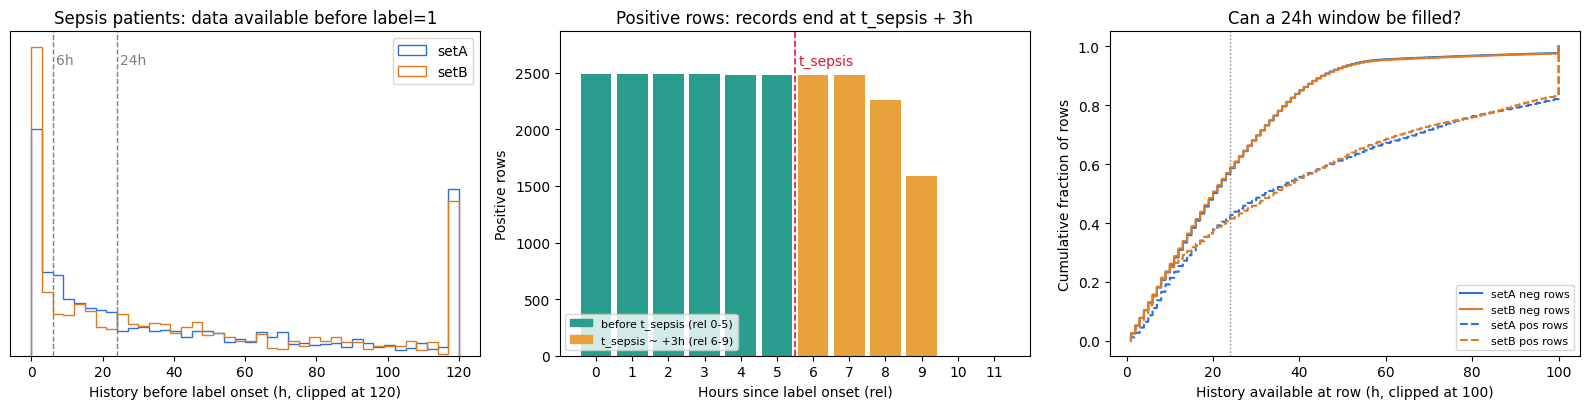

In [21]:
# Part 2-1 : 라벨과 시간 구조: 예측에 쓸 수 있는 과거가 얼마나 있는가
# 용어: label onset = SepsisLabel이 처음 1이 되는 시점 = t_sepsis - 6h (공식 라벨이 이미 6시간 앞당겨져 있음)
# history     = 그 시점까지 쌓인 기록 시간 (ICULOS - 첫 ICULOS + 1)

df2 = eda_df[['Patient_ID', 'set', 'ICULOS', 'SepsisLabel']].copy()
g2 = df2.groupby('Patient_ID')
df2['first_iculos'] = g2['ICULOS'].transform('min')
df2['history_h'] = df2['ICULOS'] - df2['first_iculos'] + 1          # 해당 행까지 사용 가능한 기록 길이

# (1) 라벨 단조성: 한 번 1이 되면 끝까지 1인가? (0으로 돌아가는 환자가 있으면 라벨 정의를 다시 봐야 함)
flips = g2['SepsisLabel'].apply(lambda s: int((s.diff() == -1).sum()))
print(f'[라벨 단조성] 1 → 0으로 돌아가는 환자 수: {int((flips > 0).sum())}')

# (2) 패혈증 환자별 시간 구조
onset_i = df2[df2['SepsisLabel'] == 1].groupby('Patient_ID')['ICULOS'].min().rename('onset_iculos')
sep = (g2.agg(set=('set', 'first'), first_iculos=('ICULOS', 'min'), last_iculos=('ICULOS', 'max'))
       .join(onset_i, how='inner'))
sep['history_before_onset_h'] = sep['onset_iculos'] - sep['first_iculos']      # 라벨 시작 전 기록 (0 = 첫 행부터 양성)
sep['hours_after_onset'] = sep['last_iculos'] - sep['onset_iculos'] + 1        # 라벨 1인 행 수

hb = sep['history_before_onset_h']
print('\n[패혈증 환자: 라벨 시작 전에 쌓인 기록]')
print(pd.DataFrame({
    'patients': sep.groupby('set').size(),
    'history_0h_%': sep.groupby('set')['history_before_onset_h'].apply(lambda x: 100 * (x == 0).mean()),
    'history<6h_%': sep.groupby('set')['history_before_onset_h'].apply(lambda x: 100 * (x < 6).mean()),
    'history<24h_%': sep.groupby('set')['history_before_onset_h'].apply(lambda x: 100 * (x < 24).mean()),
    'history_median_h': sep.groupby('set')['history_before_onset_h'].median(),
}).round(1))

print('\n[패혈증 환자: 라벨 시작 후 기록이 이어지는 시간]')
print(sep['hours_after_onset'].describe(percentiles=[.1, .25, .5, .75, .9]).round(1).to_dict())
print('  set별 중앙값:', sep.groupby('set')['hours_after_onset'].median().to_dict(),
      '| 최대:', sep.groupby('set')['hours_after_onset'].max().to_dict())

# (3) 양성 행의 구성: 공식 Utility 함수 기준 구간으로 나눔
# label onset 기준 rel = ICULOS - onset_iculos  (t_sepsis = rel 6)
# Utility 보상 구간: t_sepsis-12 ~ t_sepsis+3  →  rel -6 ~ +9
pos = df2[df2['SepsisLabel'] == 1].join(onset_i, on='Patient_ID')
pos['rel'] = pos['ICULOS'] - pos['onset_iculos']
pos['zone'] = pd.cut(pos['rel'], bins=[-1, 5, 9, np.inf],
                     labels=['0~5h: 발병 전 (조기 예측 구간)', '6~9h: 발병 직후 (Utility 보상 끝)', '10h~: 발병 이후 (보상 없음)'])
print('\n[양성 행의 시간 구성 (label onset 기준)]')
print(pos['zone'].value_counts().sort_index().to_frame('rows')
      .assign(pct=lambda d: (100 * d['rows'] / d['rows'].sum()).round(1)))

# (4) 모든 행: 24h window를 채울 수 있는가
df2['full_24h'] = df2['history_h'] >= 24
print('\n[행 단위: 24시간 기록을 모두 가진 행 비율(%)]')
print(df2.groupby(['set', 'SepsisLabel'])['full_24h'].mean().mul(100).round(1).unstack()
      .rename(columns={0: 'negative_rows', 1: 'positive_rows'}))

# (5) 비패혈증 vs 패혈증 환자의 체류 시간
los_tbl = (g2.agg(set=('set', 'first'), sepsis=('SepsisLabel', 'max'), los=('ICULOS', 'size'))
           .groupby(['set', 'sepsis'])['los'].median().unstack().rename(columns={0: 'non_sepsis', 1: 'sepsis'}))
print('\n[체류 시간 중앙값(h)]')
print(los_tbl)

# (6) 그림
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
ax = axes[0]
bins = np.arange(0, 121, 3)
for s in 'AB':
    ax.hist(hb[sep['set'] == s].clip(upper=120), bins=bins, density=True, histtype='step', lw=1.8,
            color=colors[s], label=f'set{s}')
for h in (6, 24):
    ax.axvline(h, color='gray', ls='--', lw=1)
    ax.text(h + 1, ax.get_ylim()[1] * 0.9, f'{h}h', color='gray')
ax.set_xlabel('History before label onset (h, clipped at 120)')
ax.set_title('Sepsis patients: data available before label=1')
ax.set_yticks([])
ax.legend()

ax = axes[1]
rel_counts = pos['rel'].value_counts().sort_index()
bar_colors = ['#2a9d8f' if r < 6 else '#e9a23b' for r in rel_counts.index]
ax.bar(rel_counts.index, rel_counts.values, width=0.85, color=bar_colors)
ax.axvline(5.5, color='crimson', lw=1.2, ls='--')
ax.text(5.6, rel_counts.max() * 1.03, 't_sepsis', color='crimson')
ax.set_xlim(-1, 12)
ax.set_ylim(0, rel_counts.max() * 1.15)
ax.set_xticks(range(0, 12))
ax.set_xlabel('Hours since label onset (rel)')
ax.set_ylabel('Positive rows')
ax.set_title('Positive rows: records end at t_sepsis + 3h')
ax.legend([plt.Rectangle((0, 0), 1, 1, color=c) for c in ('#2a9d8f', '#e9a23b')],
          ['before t_sepsis (rel 0-5)', 't_sepsis ~ +3h (rel 6-9)'], loc='lower left', fontsize=8)

ax = axes[2]
for lab, ls in [(0, '-'), (1, '--')]:
    for s in 'AB':
        x = np.sort(df2.loc[(df2['set'] == s) & (df2['SepsisLabel'] == lab), 'history_h'].clip(upper=100).values)
        ax.step(x, np.arange(1, len(x) + 1) / len(x), where='post', color=colors[s], ls=ls,
                label=f"set{s} {'pos' if lab else 'neg'} rows")
ax.axvline(24, color='gray', ls=':', lw=1)
ax.set_xlabel('History available at row (h, clipped at 100)')
ax.set_ylabel('Cumulative fraction of rows')
ax.set_title('Can a 24h window be filled?')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p2_label_time_structure.png', dpi=150)
plt.show()

1. 라벨은 깨끗하게 정의돼 있다.
한 번 1이 되면 끝까지 1. 그래서 "라벨이 처음 1이 되는 시점"이 환자마다 정확히 하나로 정해지고, 이걸 기준으로 시간을 정렬하는 분석이 가능하다.

2. 패혈증 환자의 기록은 t_sepsis + 3시간에서 잘려있다. 가장 중요한 발견.

라벨이 1인 행은 환자당 최대 10행. 라벨 시작(t_sepsis − 6)부터 세면 t_sepsis + 3시간에서 기록이 끝난다. 공식 Utility 함수의 보상 구간이 끝나는 지점과 정확히 같다.
Part 2 계획을 세울 때 "발병 이후 행을 학습과 평가에 포함할지 정해야 한다"고 했는데, 데이터가 이미 잘려 있어서 이 결정은 필요 없어졌다.
대신 새로운 위험이 생기는데 패혈증 환자는 기록 끝이 곧 발병 시점이다. 그래서 "전체 체류 시간"이나 "기록 종료까지 남은 시간"처럼 미래를 알아야 계산되는 값이 특징에 들어가면, 모델이 바로 정답을 알아버린다. 기준 2번(미래 데이터 금지)을 지키는 구체적인 이유가 여기 있다고 볼 수 있다.

3. 양성 행의 37%는 이미 발병한 뒤의 행이다.

rel 6-9 행은 6시간 전에 미리 예측이 아니라 이미 발병한 패혈증을 알아채는 행이다. 수치가 이미 나빠진 상태라 맞히기가 더 쉽다.
공식 평가는 이 행들을 포함하니까 데이터에서 빼지는 않는다. 다만 리포트에서 조기 예측 구간(rel 0-5)만 따로 계산한 AUROC를 함께 보여주면, 모델이 진짜 조기 예측을 하는지 증명할 수 있어 보인다.

4. 24시간 window를 채우지 못하는 경우가 기본값.

양성 행의 41%, 음성 행의 57%는 기록이 24시간 미만이다. 패혈증 환자의 23~28%는 라벨이 시작되기 전 기록이 6시간도 안 된다.
그래서 24시간이 꽉 찬 window만 쓰면 데이터의 절반 이상을 버리게 되고, 특히 입실 직후 빠르게 진행되는 패혈증을 전혀 학습하지 못한다.
결정: 기록이 있는 만큼만 쓰는 부분 window를 쓰고, history_h(쌓인 기록 시간)를 특징으로 넣는다. LSTM은 24시간 길이로 패딩하고 마스크를 두자. 환자를 빼지 않으니 분할 결과도 그대로 유지될 수 있다.

5. 기록 길이 자체가 라벨과 엮여 있다. 다음 단계로 이어지는 부분

체류 시간 중앙값은 패혈증과 비패혈증 환자가 비슷(36-37시간 대 39시간). 그래서 전체 체류 시간만으로는 구분이 안 된다.
그런데 행 단위로 보면 양성 행이 24시간 이상 기록을 가진 비율이 58-59%로, 음성 행(43%)보다 높다. 양성 행이 기록의 뒷부분에 몰려 있기 때문이다.
즉 "입실한 지 오래됐다"는 것만으로 양성일 확률이 올라가버린다. 앞에서 ICULOS 하나로 AUROC 0.635가 나왔던 이유인데 이게 진짜 신호인지 지름길인지를 살펴보자.

[시간 변수 단독 AUROC (행 단위)]
      ICULOS  history_h
all    0.635      0.635
setA   0.635      0.638
setB   0.631      0.631

[환자별 마지막 ICULOS 분포 (h)]
              count  mean   std  min   50%    90%    95%    99%    max
sepsis                                                                
non_sepsis  31793.0  37.4  15.8  8.0  39.0   54.0   57.0   59.0  336.0
sepsis       2492.0  58.9  59.1  8.0  37.0  139.9  192.0  263.2  336.0

[마지막 ICULOS > 60h 인 환자 비율(%)]
sepsis  non_sepsis  sepsis
set                       
A             0.04   35.04
B             1.15   33.26

[ICULOS > 60h 인 행] 67,392행 (5.1%) 중 패혈증 환자의 행: 80.6%  |  양성 행: 11.5%

[ICULOS AUROC 분해]
  (a) 환자 내부 (패혈증 환자 2126명 평균) : 1.000
  (b) 환자 사이 (비패혈증 행 vs 양성 행)        : 0.654
  (c) ICULOS ≤ 60 행만                          : 0.491

[시간당 신규 발병률과 위험군 구성]  share_sepsis_pts: 위험군(아직 음성인 행) 중 나중에 패혈증이 될 환자의 비율(%)
            at_risk_rows  onsets  share_sepsis_pts  onset_per_1000h
iculos_bin                                                   

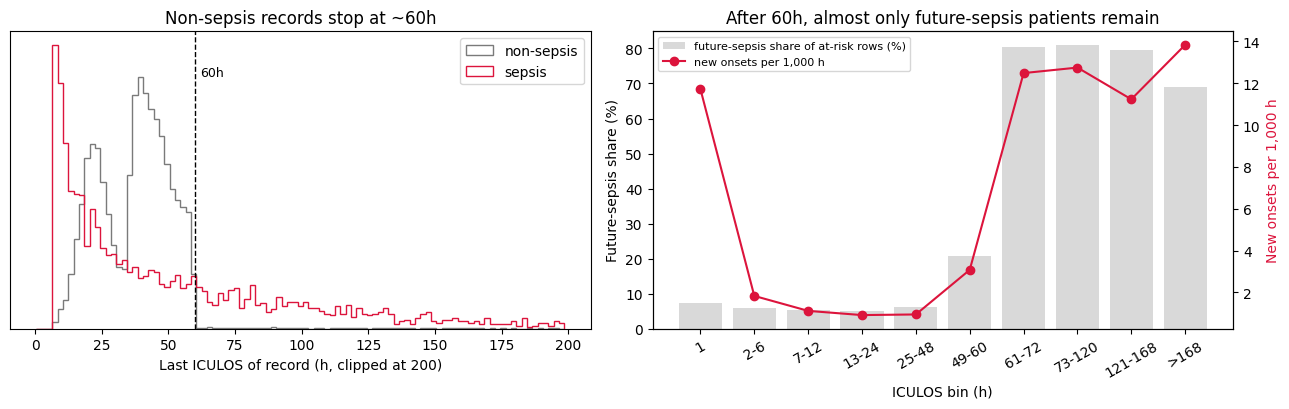

In [22]:
# Part 2-2 : 시간 지름길 확인: ICULOS는 진짜 신호인가, 데이터 구성의 부산물인가
from sklearn.metrics import roc_auc_score

t = eda_df[['Patient_ID', 'set', 'ICULOS', 'SepsisLabel']].copy()
gt = t.groupby('Patient_ID')
t['history_h'] = t['ICULOS'] - gt['ICULOS'].transform('min') + 1     # 기록 시작 이후 경과 시간
t['is_sepsis_pt'] = gt['SepsisLabel'].transform('max')
y = t['SepsisLabel']


def auc(y_true: pd.Series, score: pd.Series) -> float:
    """AUROC; returns NaN when only one class is present."""
    return roc_auc_score(y_true, score) if y_true.nunique() == 2 else np.nan


# (1) 시간 변수 하나만으로 얼마나 맞히는가 (행 단위 AUROC)
print('[시간 변수 단독 AUROC (행 단위)]')
print(pd.DataFrame({
    'ICULOS': [auc(y, t['ICULOS'])] + [auc(y[t.set == s], t.loc[t.set == s, 'ICULOS']) for s in 'AB'],
    'history_h': [auc(y, t['history_h'])] + [auc(y[t.set == s], t.loc[t.set == s, 'history_h']) for s in 'AB'],
}, index=['all', 'setA', 'setB']).round(3))

# (2) 기록 길이 분포: 패혈증 여부별 (데이터 구성 방식 확인)
los = gt.agg(set=('set', 'first'), sepsis=('SepsisLabel', 'max'), last=('ICULOS', 'max'), rows=('ICULOS', 'size'))
print('\n[환자별 마지막 ICULOS 분포 (h)]')
print(los.groupby('sepsis')['last'].describe(percentiles=[.5, .9, .95, .99]).round(1)
      .rename(index={0: 'non_sepsis', 1: 'sepsis'}))
print('\n[마지막 ICULOS > 60h 인 환자 비율(%)]')
print(los.groupby(['set', 'sepsis'])['last'].apply(lambda x: round(100 * (x > 60).mean(), 2)).unstack()
      .rename(columns={0: 'non_sepsis', 1: 'sepsis'}))

late = t[t['ICULOS'] > 60]
print(f"\n[ICULOS > 60h 인 행] {len(late):,}행 ({100 * len(late) / len(t):.1f}%) 중 "
      f"패혈증 환자의 행: {100 * late['is_sepsis_pt'].mean():.1f}%  |  양성 행: {100 * late['SepsisLabel'].mean():.1f}%")

# (3) AUROC 분해
# (a) 환자 내부: 패혈증 환자 안에서 음성 행 vs 양성 행 → 라벨이 시간 순 0→1 이므로 구조적으로 1.0
# (b) 환자 사이: 비패혈증 환자의 행 vs 양성 행
# (c) ICULOS ≤ 60 행만: 기록 잘림의 영향을 뺀 AUROC
within = [auc(gg['SepsisLabel'], gg['ICULOS'])
          for _, gg in t[t['is_sepsis_pt'] == 1].groupby('Patient_ID') if gg['SepsisLabel'].nunique() == 2]
between_mask = (t['is_sepsis_pt'] == 0) | (t['SepsisLabel'] == 1)
le60 = t['ICULOS'] <= 60
print('\n[ICULOS AUROC 분해]')
print(f"  (a) 환자 내부 (패혈증 환자 {len(within)}명 평균) : {np.mean(within):.3f}")
print(f"  (b) 환자 사이 (비패혈증 행 vs 양성 행)        : {auc(y[between_mask], t.loc[between_mask, 'ICULOS']):.3f}")
print(f"  (c) ICULOS ≤ 60 행만                          : {auc(y[le60], t.loc[le60, 'ICULOS']):.3f}")

# (4) 시간당 신규 발병률: 그 시간까지 음성이던 행 중 이번 시간에 처음 1이 되는 비율
t['onset_now'] = (t['SepsisLabel'] == 1) & (gt['SepsisLabel'].shift(fill_value=0) == 0)
at_risk = t[(t['SepsisLabel'] == 0) | t['onset_now']].copy()
bins = [0, 1, 6, 12, 24, 48, 60, 72, 120, 168, np.inf]
labels = ['1', '2-6', '7-12', '13-24', '25-48', '49-60', '61-72', '73-120', '121-168', '>168']
at_risk['iculos_bin'] = pd.cut(at_risk['ICULOS'], bins=bins, labels=labels)
hz = at_risk.groupby('iculos_bin', observed=True).agg(
    at_risk_rows=('onset_now', 'size'), onsets=('onset_now', 'sum'),
    share_sepsis_pts=('is_sepsis_pt', 'mean'))
hz['onset_per_1000h'] = 1000 * hz['onsets'] / hz['at_risk_rows']
hz['share_sepsis_pts'] *= 100
print('\n[시간당 신규 발병률과 위험군 구성]  share_sepsis_pts: 위험군(아직 음성인 행) 중 나중에 패혈증이 될 환자의 비율(%)')
print(hz.round(2))

# (5) 그래프: (왼쪽) 마지막 ICULOS 분포, (오른쪽) 구간별 위험군 구성과 신규 발병률
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
b = np.arange(0.5, 200.5, 2)
for sp, c, lab in [(0, '#7a7a7a', 'non-sepsis'), (1, 'crimson', 'sepsis')]:
    ax.hist(los.loc[los['sepsis'] == sp, 'last'].clip(upper=199), bins=b, density=True,
            histtype='step', lw=1.8, color=c, label=lab)
ax.axvline(60, color='black', ls='--', lw=1)
ax.text(62, ax.get_ylim()[1] * 0.85, '60h', fontsize=9)
ax.set_xlabel('Last ICULOS of record (h, clipped at 200)')
ax.set_title('Non-sepsis records stop at ~60h')
ax.set_yticks([])
ax.legend(loc='upper right')

ax = axes[1]
x = np.arange(len(hz))
ax.bar(x, hz['share_sepsis_pts'], color='#d9d9d9', label='future-sepsis share of at-risk rows (%)')
ax.set_ylabel('Future-sepsis share (%)')
ax.set_xticks(x, hz.index, rotation=30)
ax.set_xlabel('ICULOS bin (h)')
ax2 = ax.twinx()
ax2.plot(x, hz['onset_per_1000h'], marker='o', color='crimson', label='new onsets per 1,000 h')
ax2.set_ylabel('New onsets per 1,000 h', color='crimson')
ax.set_title('After 60h, almost only future-sepsis patients remain')
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p2_time_shortcut.png', dpi=150)
plt.show()

1. 비패혈증 환자의 기록은 약 60시간에서 잘려 있다.

비패혈증 환자 99%가 59시간 안에 기록이 끝난다. 히스토그램을 보면 60시간에서 절벽처럼 떨어진다. 반면 패혈증 환자는 최대 336시간까지 기록이 이어진다.
실제 ICU에서 비패혈증 환자가 모두 60시간 안에 퇴실할 리는 없다. 그래서 이건 대회 주최 측이 데이터를 만들 때 비패혈증 환자의 기록 구간을 잘라낸 흔적으로 봐야 한다고 본다. 비패혈증 분포가 약 22시간과 약 40시간에 봉우리가 두 개인 것도 같은 맥락.
결과적으로 60시간이 지나면 남아 있는 환자의 80%가 "나중에 패혈증이 될 환자"임.

2. ICULOS의 AUROC 0.635는 전부 이 부산물에서 나옴.

ICULOS ≤ 60인 행만 보면 AUROC가 0.491로, yes or no 수준이다. 이 구간에서는 입실 시간이 패혈증에 대해 아무 정보도 주지 않는다.
신규 발병률이 60시간 이후 급등하는 것도 임상적 현상이 아니라고 본다. 위험군 구성이 바뀌어서 생긴 착시정도?
환자 내부 AUROC가 1.000인 것도 같은 맥락이다. 패혈증 환자 안에서는 라벨이 시간 순서대로 0에서 1로 바뀌니까, 시간이 흐른다는 사실만으로 완벽하게 순서가 맞아진다.

3. 실제 배포 환경에서 이 모델은 위험하다.
ICULOS를 학습한 모델은 “60시간 넘게 입원 = 패혈증 위험”을 배울텐데, 실제 병원에서는 60시간 넘게 머무는 비패혈증 환자가 많으니까, 장기 입원 환자 전원에게 경보가 울리게 된다. 명세가 강조하는 Alert Fatigue를 정면으로 일으키는 구조이다.

결정할 것 : 항목 / 추천 / 이유

ICULOS, history_h	/ 특징에서 제외	/ 60시간 이하 구간에서 예측력이 0.491로 없고, 신호 전체가 데이터 구성의 부산물이다.

절대 시간을 담는 특징 (누적 측정 횟수, 입실 후 누적 최댓값 같은 전체 체류 통계)	/ 제외 / 시간이 지날수록 커지는 값이라 ICULOS와 똑같은 지름길이 된다.

window 관찰 시간 / 24시간을 상한으로 두고 사용 / 상한(24)이 60보다 작아서 지름길이 될 수 없다.

LSTM 입력	/ 24시간 window만 사용 / 입실부터의 전체 시퀀스를 넣으면 시퀀스 길이 자체가 시간 정보가 된다.

평가 / ICULOS ≤ 60 행만 따로 계산한 성능도 보고 / 모델이 시간 지름길에 의존하는지 확인할 수 있다. 리포트에서 강한 근거가 된다.

앞 설명 정정 부분:
Part 2-1의 "전체 체류 시간만으로는 구분이 안 된다"는 틀렸다. 중앙값은 비슷하지만 꼬리가 완전히 다르다. 기록이 60시간을 넘으면 거의 확실하게 패혈증 환자이다.
Part 2 계획 단계에서 “ICULOS를 넣은 모델과 뺀 모델을 둘 다 돌려보자”고 했는데, 이제는 빼는 걸 기본으로 하고 넣은 모델은 리포트에서 지름길을 보여주는 비교 실험용으로만 쓰는 게 맞아보인다.
"누적 측정 횟수의 AUROC가 0.65-0.67"이었던 것도 이 부산물에 오염돼 있었을 가능성이 크니 다음 단계(Part 2-3)에서 24시간 window 안의 측정률로 바꿔서 다시 확인해보자.

[측정 패턴 특징의 AUROC]  (0.5 = 정보 없음)
                 cum_all  win24_all  win24_le60  win24_le60_A  win24_le60_B  \
var                                                                           
FiO2               0.673      0.636       0.617         0.591         0.627   
Lactate            0.652      0.586       0.596         0.592         0.590   
PaCO2              0.658      0.602       0.594         0.545         0.627   
pH                 0.657      0.602       0.592         0.541         0.627   
Alkalinephos       0.605      0.547       0.557         0.556         0.569   
AST                0.606      0.547       0.557         0.555         0.569   
Bilirubin_total    0.602      0.545       0.554         0.552         0.569   
Phosphate          0.660      0.584       0.549         0.544         0.530   
Calcium            0.663      0.572       0.543         0.544         0.566   
PTT                0.616      0.544       0.543         0.514         0.537   
Magnesium          

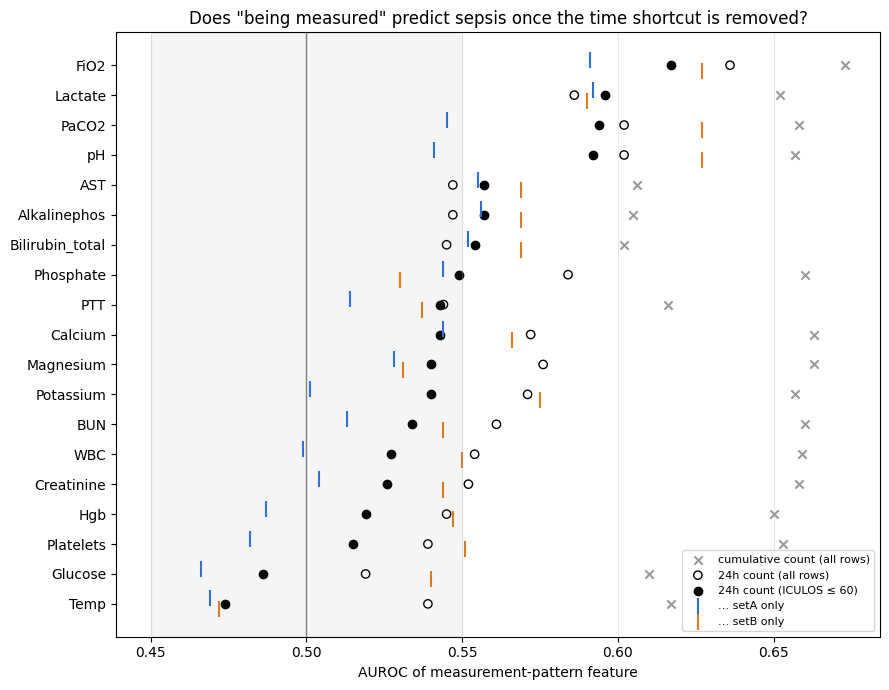

In [23]:
# Part 2-3 : 결측 패턴과 라벨의 관계: '측정했다는 사실'이 진짜 신호인가?
# 2-2에서 확인한 시간 지름길을 피하기 위해 3가지 방식으로 비교
# cum   : 입실 후 누적 측정 횟수           → 시간이 지날수록 커짐 (지름길에 오염)
# win24 : 최근 24시간 안의 측정 횟수 (0~24) → 시간 상한이 있음
# since : 마지막 측정 이후 경과 시간 (48h 상한, 한 번도 없으면 48)
# 그리고 ICULOS ≤ 60 행에서 다시 계산해 지름길의 영향을 제거, set별로 나눠 병원 혼동도 확인
import json
from sklearn.metrics import roc_auc_score
if 'config' not in globals():                       # Part 1 결론 셀의 설정을 다시 불러옴
    with open('artifacts/preprocess_config.json', encoding='utf-8') as f:
        config = json.load(f)

MISS_VARS = ['Temp', 'Lactate', 'WBC', 'Creatinine', 'Platelets', 'BUN', 'Bilirubin_total', 'Glucose',
             'Hgb', 'Potassium', 'Magnesium', 'Phosphate', 'Calcium', 'AST', 'Alkalinephos',
             'FiO2', 'pH', 'PaCO2', 'PTT']
WIN, SINCE_CAP = 24, 48

m = eda_df[['Patient_ID', 'set', 'ICULOS', 'SepsisLabel'] + MISS_VARS].copy()
gm = m.groupby('Patient_ID')
feat = {}
for v in MISS_VARS:
    meas = m[v].notna().astype(int)
    cum = meas.groupby(m['Patient_ID']).cumsum()
    feat[f'{v}|cum'] = cum
    # 최근 24행(=24시간, 각 환자 기록은 1시간 간격으로 빈틈없음) 안의 측정 횟수
    feat[f'{v}|win24'] = cum - cum.groupby(m['Patient_ID']).shift(WIN, fill_value=0)
    last_t = m['ICULOS'].where(m[v].notna()).groupby(m['Patient_ID']).ffill()
    feat[f'{v}|since'] = (m['ICULOS'] - last_t).fillna(SINCE_CAP).clip(upper=SINCE_CAP)
feat = pd.DataFrame(feat)

y = m['SepsisLabel']
le60 = m['ICULOS'] <= 60
masks = {'all': pd.Series(True, index=m.index), 'le60': le60,
         'le60_A': le60 & (m['set'] == 'A'), 'le60_B': le60 & (m['set'] == 'B')}


def signed_auc(y_true: pd.Series, score: pd.Series) -> float:
    """AUROC (>0.5: higher score → sepsis, <0.5: lower score → sepsis)."""
    return roc_auc_score(y_true, score)


rows = []
for v in MISS_VARS:
    r = {'var': v}
    r['cum_all'] = signed_auc(y, feat[f'{v}|cum'])
    for k in ['all', 'le60', 'le60_A', 'le60_B']:
        r[f'win24_{k}'] = signed_auc(y[masks[k]], feat.loc[masks[k], f'{v}|win24'])
    r['since_le60'] = signed_auc(y[le60], feat.loc[le60, f'{v}|since'])
    rows.append(r)
mauc = pd.DataFrame(rows).set_index('var').round(3)

# 판정: ICULOS≤60에서 win24 AUROC ≥ 0.55, 양쪽 병원 모두 ≥ 0.53 이면 '측정 신호 있음'
no_ind = set(config['no_indicator_features']) | set(config['excluded_features'])
mauc['signal'] = np.where((mauc['win24_le60'] >= 0.55) & (mauc[['win24_le60_A', 'win24_le60_B']].min(axis=1) >= 0.53),
                          'yes', '')
mauc['blocked_by_part1'] = ['yes' if v in no_ind else '' for v in mauc.index]
print('[측정 패턴 특징의 AUROC]  (0.5 = 정보 없음)')
print(mauc.sort_values('win24_le60', ascending=False))

# 요약: 누적 횟수 → 24h 횟수 → ICULOS≤60 로 갈수록 AUROC가 얼마나 줄어드는가
print('\n[평균 AUROC 변화]  cum_all → win24_all → win24_le60')
print(mauc[['cum_all', 'win24_all', 'win24_le60']].mean().round(3).to_dict())

# 측정 신호가 있는 변수: 측정 직전·직후의 양성 비율 (측정 '이유'가 위험 신호인지 확인)
sig_vars = mauc.index[mauc['signal'] == 'yes'].tolist()
print('\n[측정 신호가 있는 변수]', sig_vars)
if sig_vars:
    rate = pd.DataFrame({v: m.loc[le60].groupby(feat.loc[le60, f'{v}|win24'].clip(upper=6))['SepsisLabel'].mean() * 100
                         for v in sig_vars}).round(2)
    rate.index.name = 'win24 count (6=6+)'
    print('[ICULOS≤60 행: 최근 24h 측정 횟수별 양성 비율(%)]')
    print(rate)

# 그림: 변수별 AUROC (누적 → 24h → 24h & ICULOS≤60, 그리고 set별)
order = mauc.sort_values('win24_le60').index
fig, ax = plt.subplots(figsize=(9, 7))
yy = np.arange(len(order))
ax.scatter(mauc.loc[order, 'cum_all'], yy, marker='x', color='#9a9a9a', label='cumulative count (all rows)')
ax.scatter(mauc.loc[order, 'win24_all'], yy, marker='o', facecolors='none', edgecolors='black', label='24h count (all rows)')
ax.scatter(mauc.loc[order, 'win24_le60'], yy, marker='o', color='black', label='24h count (ICULOS ≤ 60)')
ax.scatter(mauc.loc[order, 'win24_le60_A'], yy + 0.18, marker='|', s=120, color=colors['A'], label='… setA only')
ax.scatter(mauc.loc[order, 'win24_le60_B'], yy - 0.18, marker='|', s=120, color=colors['B'], label='… setB only')
ax.axvline(0.5, color='gray', lw=1)
ax.axvspan(0.45, 0.55, color='gray', alpha=0.08)
ax.set_yticks(yy, order)
ax.set_xlabel('AUROC of measurement-pattern feature')
ax.set_title('Does "being measured" predict sepsis once the time shortcut is removed?')
ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p2_missingness_label.png', dpi=150)
plt.show()

1. 누적 측정 횟수의 높은 AUROC는 대부분 시간 지름길이었다.

평균 AUROC가 0.643에서 0.545로 떨어진다. 앞에서 "누적 측정 횟수만으로 AUROC 0.65-0.67"이라고 했던 결과는 거의 전부 60시간 기록 잘림 때문. 누적 측정 횟수는 특징에서 제외해야 한다.

2. 진짜 신호는 "의사가 의심할 때만 하는 검사"에서만 남는다.

시간 지름길을 걷어내고도 신호가 남는 건 Lactate, 혈액가스(FiO2, pH, PaCO2), 간 기능 검사이다. 공통점은 정기적으로 하는 검사가 아니라 의사가 상태 악화를 의심할 때 추가로 내는 검사라는 점이다. 그래서 "검사를 냈다"는 사실이 곧 의료진의 판단을 반영한다고 볼 수 있다.
반대로 WBC, Creatinine, Platelets 같은 일반 혈액검사는 매일 하는 검사라서 측정 여부에 정보가 없다(A에서 0.48~0.51). B에서만 약간의 신호가 보이는 건 병원 관행 차이로 봐야 할 것 같다.
이 결과가 Part 1의 결측을 세 종류로 나눴던 것 중 ”임상 판단 때문에 생긴 결측"을 데이터로 확인한 것

3. 횟수보다 "측정 여부"와 "최근성"이 핵심이다.

0회에서 1회로 갈 때만 양성 비율이 크게 오르고, 그 이후는 일정하지 않다. 그래서 측정 횟수 그대로보다 최근 24시간 측정 여부(0/1)가 더 적절하다.
마지막 측정 이후 시간(since)도 AUROC가 0.36-0.39이다. 뒤집으면 0.61-0.64라서 횟수보다 약간 더 강한 신호이다. 최근에 측정했을수록 위험하다는 뜻이 된다.

4. Part 1의 차단 결정과 충돌하는 부분이 존재한다.

pH와 PaCO2는 신호가 있지만 A 0.54 대 B 0.63으로 병원 간 차이가 크다. 그래서 Part 1에서 indicator를 차단한 결정을 유지하는 게 맞다.
같은 혈액가스 정보는 FiO2 indicator가 대신 담을 수 있다. FiO2는 두 병원 모두 신호가 뚜렷하다(0.59 / 0.63). 다만 FiO2의 병원 간 never-measured 차이가 29.9%p로, Part 1 차단 기준(30%p)에 아슬아슬하게 안 걸린 경계 사례라는 점은 리포트에 남겨두는 게 좋아보인다.
결정할 것 : 항목 / 추천

측정 패턴 특징을 만들 변수 / Lactate, FiO2, 간 기능 묶음 (AST, Alkalinephos, Bilirubin_total은 같이 처방되니까 하나의 indicator로 묶기)

특징 형태	/ 최근 24시간 측정 여부 (0/1) + 마지막 측정 이후 시간 (48시간 상한)

일반 혈액검사	/ 값만 쓰고 측정 패턴 특징은 만들지 않음

누적 측정 횟수 / 전부 제외 (시간 지름길)

SHAP 해석	/ 측정 패턴 특징이 상위에 나오면 "의료진이 이미 의심하고 검사를 냈다"는 의미라는 점을 리포트와 대시보드에서 명시

[현재 값(forward fill) 단독 AUROC, ICULOS ≤ 60 행]  strength = max(|raw-0.5|, |deviation-0.5|) + 0.5
                 coverage_%  auc_raw  auc_A  auc_B  auc_deviation  strength  \
var                                                                           
HR                   97.585    0.603  0.592  0.614          0.570     0.603   
Temp                 92.203    0.580  0.568  0.585          0.599     0.599   
BUN                  78.388    0.584  0.572  0.598            NaN     0.584   
Resp                 96.647    0.567  0.578  0.549          0.581     0.581   
WBC                  76.335    0.569  0.541  0.598          0.579     0.579   
Creatinine           77.472    0.574  0.565  0.597            NaN     0.574   
FiO2                 41.521    0.567  0.542  0.609            NaN     0.567   
MAP                  97.068    0.439  0.464  0.435          0.535     0.561   
SBP                  95.965    0.444  0.458  0.439          0.524     0.556   
Calcium              68.840    0.444

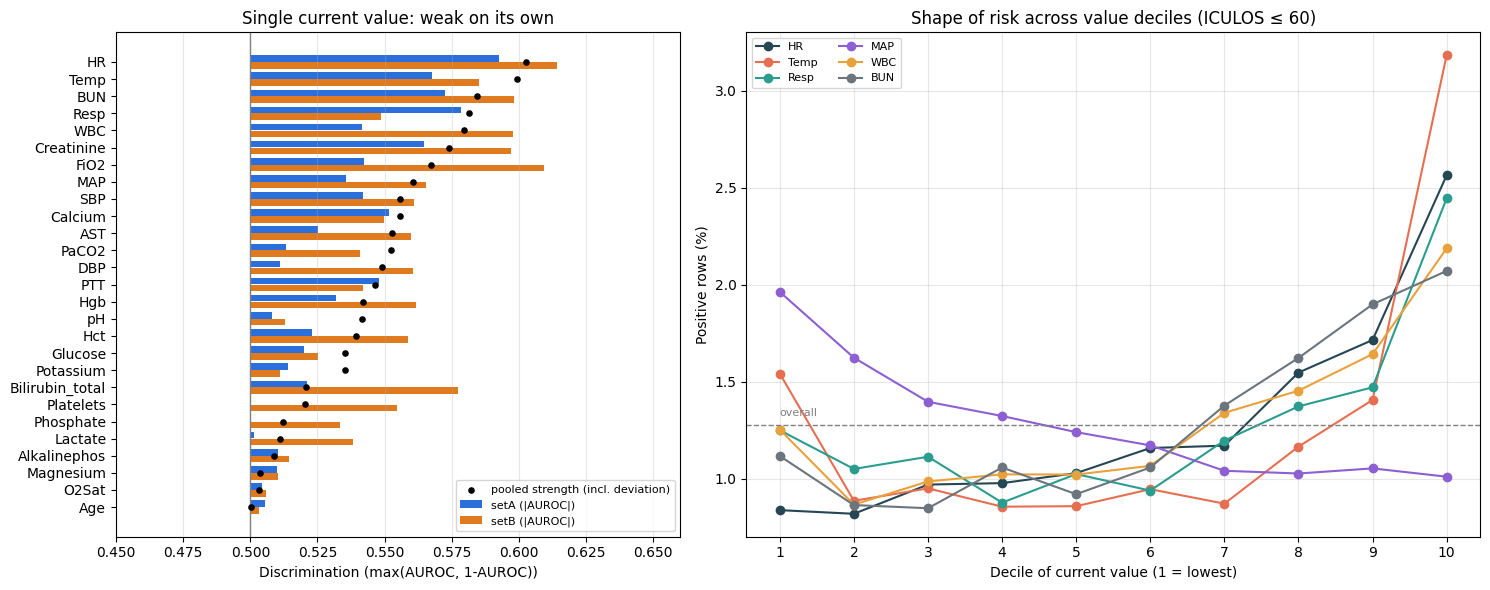

In [24]:
# Part 2-4 : 단일 변수 판별력: 값 하나만으로는 얼마나 맞히는가, window 통계가 필요한가
# 원칙: (1) Part 1 정제 규칙을 적용한 값 사용  (2) 환자 내부 forward fill (과거 값만 사용, 기준 2)
# (3) 2-2의 시간 지름길을 피하려고 ICULOS ≤ 60 행에서만 AUROC 계산  (4) set별로도 확인
if 'apply_cleaning' in globals():
    clean_df, _ = apply_cleaning(eda_df)
else:
    raise RuntimeError('Part 1 품질 정리 셀(apply_cleaning)을 먼저 실행하세요.')

excluded = set(config['excluded_features'])
VALUE_VARS = [v for v in ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp',
                          'Lactate', 'WBC', 'Platelets', 'Creatinine', 'BUN', 'Bilirubin_total', 'AST',
                          'Alkalinephos', 'Glucose', 'Hgb', 'Hct', 'Potassium', 'Magnesium', 'Phosphate',
                          'Calcium', 'FiO2', 'pH', 'PaCO2', 'PTT', 'Age'] if v not in excluded]

c = clean_df[['Patient_ID', 'set', 'ICULOS', 'SepsisLabel'] + VALUE_VARS].copy()
ff = c.groupby('Patient_ID')[VALUE_VARS].ffill()               # 과거 값만 앞으로 채움
yc = c['SepsisLabel']
le60c = c['ICULOS'] <= 60

# 정상 범위 중심: '정상에서 얼마나 벗어났나'(U자형 관계) 확인용
NORMAL_CENTER = {'Temp': 37.0, 'HR': 80, 'Resp': 16, 'WBC': 8.0, 'Glucose': 110, 'pH': 7.40,
                 'PaCO2': 40, 'Potassium': 4.2, 'MAP': 85, 'SBP': 120}


def auc_on(mask: pd.Series, score: pd.Series) -> float:
    """AUROC on rows where mask is True and score is present."""
    ok = mask & score.notna()
    return roc_auc_score(yc[ok], score[ok]) if yc[ok].nunique() == 2 else np.nan


rows = []
for v in VALUE_VARS:
    x = ff[v]
    r = {'var': v, 'coverage_%': 100 * x[le60c].notna().mean(),
         'auc_raw': auc_on(le60c, x),
         'auc_A': auc_on(le60c & (c['set'] == 'A'), x),
         'auc_B': auc_on(le60c & (c['set'] == 'B'), x)}
    if v in NORMAL_CENTER:
        r['auc_deviation'] = auc_on(le60c, (x - NORMAL_CENTER[v]).abs())
    rows.append(r)
uni = pd.DataFrame(rows).set_index('var')
uni['strength'] = (uni[['auc_raw', 'auc_deviation']].apply(lambda s: (s - 0.5).abs()).max(axis=1) + 0.5)
uni['direction'] = np.where(uni['auc_raw'] >= 0.5, 'high→sepsis', 'low→sepsis')
uni['A_B_gap'] = (uni['auc_A'] - uni['auc_B']).abs()
print('[현재 값(forward fill) 단독 AUROC, ICULOS ≤ 60 행]  strength = max(|raw-0.5|, |deviation-0.5|) + 0.5')
print(uni.sort_values('strength', ascending=False).round(3))

# window 통계가 현재 값보다 나은가: 활력징후 5개, 최근 24시간 통계
WIN_VARS = ['HR', 'Temp', 'Resp', 'MAP', 'O2Sat']
gw = c.groupby('Patient_ID')
win_rows = []
for v in WIN_VARS:
    roll = gw[v].rolling(24, min_periods=1)
    stats_ = {
        'current(ffill)': ff[v],
        'mean24': roll.mean().reset_index(level=0, drop=True),
        'max24': roll.max().reset_index(level=0, drop=True),
        'min24': roll.min().reset_index(level=0, drop=True),
        'std24': roll.std().reset_index(level=0, drop=True),
        'delta6h': ff[v] - ff.groupby(c['Patient_ID'])[v].shift(6),     # 6시간 전 대비 변화
    }
    r = {'var': v}
    for k, s in stats_.items():
        a = auc_on(le60c, s)
        r[k] = max(a, 1 - a)                                            # 방향과 무관한 판별력
    win_rows.append(r)
win_tbl = pd.DataFrame(win_rows).set_index('var').round(3)
win_tbl['best'] = win_tbl.idxmax(axis=1)
print('\n[활력징후: 현재 값 vs 최근 24시간 통계, 방향 무관 AUROC (ICULOS ≤ 60)]')
print(win_tbl)

# 그래프: (왼쪽) 변수별 판별력 막대(A/B), (오른쪽) U자형 관계 확인 — 십분위별 양성 비율
top = uni.sort_values('strength', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1.3]})
ax = axes[0]
yy = np.arange(len(top))[::-1]
for s, off in [('A', 0.2), ('B', -0.2)]:
    vals = top[f'auc_{s}'].apply(lambda a: max(a, 1 - a))
    ax.barh(yy + off, vals - 0.5, left=0.5, height=0.38, color=colors[s], label=f'set{s} (|AUROC|)')
ax.scatter(top['strength'], yy, color='black', s=14, zorder=3, label='pooled strength (incl. deviation)')
ax.set_yticks(yy, top.index)
ax.axvline(0.5, color='gray', lw=1)
ax.set_xlim(0.45, 0.66)
ax.set_xlabel('Discrimination (max(AUROC, 1-AUROC))')
ax.set_title('Single current value: weak on its own')
ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='x', alpha=0.3)

ax = axes[1]
for v, col in zip(['HR', 'Temp', 'Resp', 'MAP', 'WBC', 'BUN'],
                  ['#264653', '#e76f51', '#2a9d8f', '#8d5fd3', '#e9a23b', '#6c757d']):
    x = ff.loc[le60c, v]
    ok = x.notna()
    q = pd.qcut(x[ok].rank(method='first'), 10, labels=False)
    pr = yc[le60c][ok].groupby(q).mean() * 100
    ax.plot(np.arange(1, 11), pr.values, marker='o', color=col, label=v)
ax.axhline(100 * yc[le60c].mean(), color='gray', ls='--', lw=1)
ax.text(1, 100 * yc[le60c].mean() + 0.05, 'overall', color='gray', fontsize=8)
ax.set_xticks(range(1, 11))
ax.set_xlabel('Decile of current value (1 = lowest)')
ax.set_ylabel('Positive rows (%)')
ax.set_title('Shape of risk across value deciles (ICULOS ≤ 60)')
ax.legend(fontsize=8, loc='upper left', ncol=2)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p2_univariate.png', dpi=150)
plt.show()

1. 값 하나만으로는 판별력이 약하다.
가장 강한 HR도 0.603이고, 명세 목표(AUROC 0.82)와 거리가 멀다. 결국 여러 변수를 조합하는 다변량 모델이 꼭 필요하다는 말이다. 리포트의 특징 추출 섹션 도입부에 쓸 수 있는 근거이다.

2. 체온은 U자형이라 처리 방식이 달라야 한다.

오른쪽 그림에서 체온은 가장 낮은 10%(저체온)와 가장 높은 10%(발열) 양쪽 끝에서 위험이 올라간다. 패혈증의 SIRS 기준(38°C 초과 또는 36°C 미만)과 정확히 일치한다.
트리 모델(XGBoost, LightGBM)은 U자형을 스스로 학습하지만, LSTM이나 선형 모델은 |Temp − 37| 같은 편차 특징을 따로 넣어주는 게 좋다.
PaCO2와 pH도 원값은 0.48-0.50인데, 정상에서 벗어난 거리로 보면 0.54-0.55로 올라간다. 산증과 알칼리증 둘 다 위험하기 때문이다.

3. Lactate는 값보다 "측정했다는 사실"이 더 중요하다.

Lactate 값 자체는 0.511로 거의 정보가 없지만, 2-3에서 본 측정 여부는 0.596이었다.
패혈증 기준(2 mmol/L 이상)으로 알려진 변수인데 의외의 결과이다. 이유는 측정된 환자가 28%뿐이고, 이미 의심받은 환자만 측정되기 때문이다. 측정된 사람들끼리는 값 차이로 구분이 잘 안 되는 것이다.
그래서 Lactate는 값 특징과 측정 패턴 특징을 둘 다 넣는 게 맞다고 본다.

4. window 통계가 단독으로는 현재 값보다 크게 낫지 않다. 앞 설명을 하나 정정해야 한다.

처음 Part 2 계획을 세울 때 "값 하나로는 약하니 window 통계가 필요하다는 근거가 된다"고 했는데, 실제로 window 통계를 하나씩 따로 보면 현재 값과 비슷한 수준(±0.02)이다. 6시간 변화량이나 표준편차도 단독으로는 약하다(0.50~0.54).
그래서 window 통계가 필요한 근거는 "단독 판별력이 더 높아서"가 아니라 변수마다 최적의 통계가 달라서이다. HR은 현재 값, Resp는 평균, MAP는 최솟값, Temp는 최댓값이 가장 좋다. 그래서 여러 통계를 같이 넣고 모델이 고르게 하는 게 맞다.
추세 정보는 다른 변수와 조합될 때 의미가 생긴다. 이건 단변량 분석으로는 확인할 수 없고, 다음 단계(2-5)와 모델 학습 후 SHAP으로 확인해야 한다.
더군다나 명세 요구사항이기도 함.

5. 병원 간 판별력 차이가 큰 변수가 있다.
Bilirubin_total(A 0.479, B 0.577, 차이 0.098), FiO2(차이 0.067), WBC(0.056), Platelets(0.055)는 한쪽 병원에서만 신호가 강하다. 이 변수들이 SHAP 상위에 나오면 A→B 교차 실험에서 성능이 떨어지는지 확인해야 한다.

6. Age는 판별력이 없다.
고령이 패혈증 위험 요인으로 알려져 있지만, 이 데이터에서는 이미 ICU에 들어온 환자끼리 비교하는 거라 나이 차이가 정보를 주지 않는다. 특징으로 넣어도 되지만 기여도는 낮을 것으로 보인다.

패혈증 환자 551명 (T 이전 24h 기록 보유, T ≤ 60h) | 매칭 비교군 5,510건 (고유 환자 4,582명)
T(ICULOS) 중앙값 — 패혈증: 40.0 / 비교군: 40.0 | KS: 0.0

[시점별 SMD (패혈증 - 비교군)]  |SMD| ≥ 0.2 의미 있는 차이
                    T-24h  T-12h  T-6h  T (label onset)  T+6h (t_sepsis)  T+9h
HR                   0.19   0.21  0.26             0.35             0.46  0.36
Temp                 0.13   0.17  0.24             0.40             0.50  0.48
Resp                 0.15   0.18  0.22             0.18             0.26  0.17
MAP                 -0.08  -0.17 -0.14            -0.13            -0.19 -0.30
SBP                 -0.03  -0.12 -0.09            -0.09            -0.15 -0.22
O2Sat               -0.03   0.05 -0.01             0.00            -0.09 -0.00
WBC                  0.18   0.15  0.18             0.22             0.28  0.25
BUN                  0.07   0.12  0.14             0.15             0.17  0.16
Creatinine           0.09   0.11  0.12             0.13             0.14  0.15
Platelets           -0.08  -0.08 -0.08          

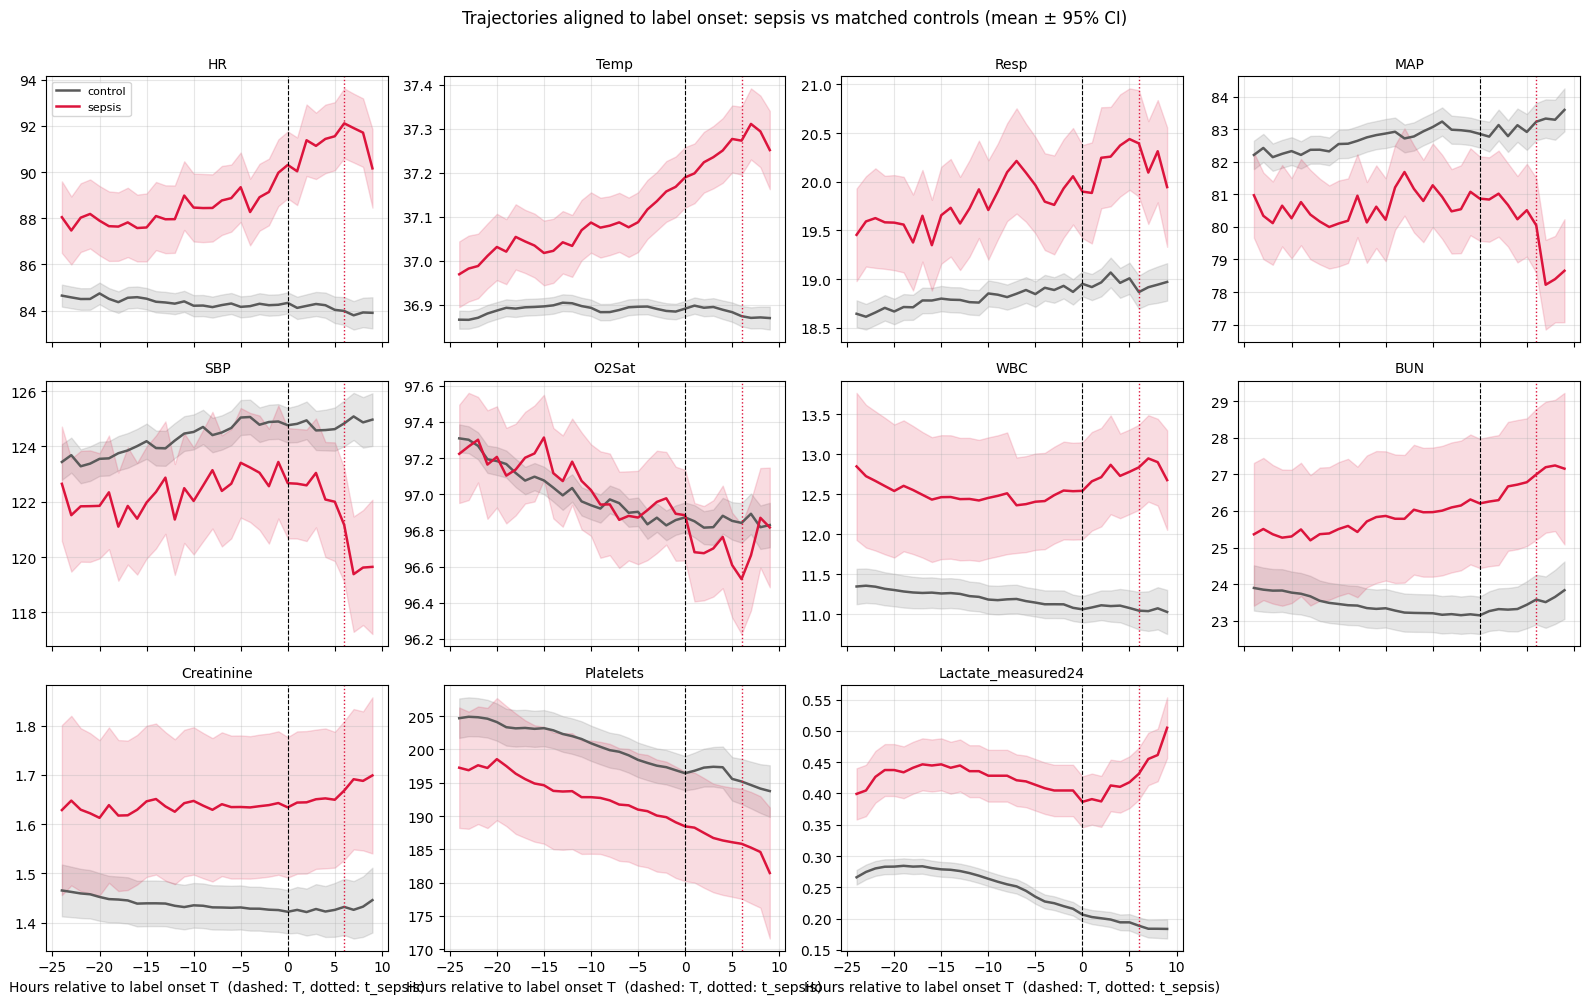

In [25]:
# Part 2-5 : 발병 시점 기준 궤적: 패혈증 환자는 언제부터, 무엇이, 어떻게 달라지는가
# 설계
#  - 패혈증 환자: 기준 시점 T = label onset (SepsisLabel이 처음 1, = t_sepsis - 6h)
#  - 비교군(비패혈증): 위험군 매칭으로 같은 T를 부여 (입실 시간이 같은 시점끼리 공정 비교)
#  - 두 그룹 모두 T 이전 24시간 기록이 있는 환자만 사용 → 구간마다 환자 구성이 바뀌는 착시 방지
#  - 두 그룹 모두 T ≤ 60h 로 제한 → 비패혈증 기록이 60h에서 잘리는 문제(2-2)로 기준 시점이 어긋나는 것 방지
#  - 값은 정제 후 환자 내부 forward fill (과거 값만 사용)
TRAJ_VARS = ['HR', 'Temp', 'Resp', 'MAP', 'SBP', 'O2Sat', 'WBC', 'BUN', 'Creatinine', 'Platelets']
PRE, POST, SEED, T_MAX = 24, 9, 42, 60

if 'clean_df' not in globals():
    clean_df, _ = apply_cleaning(eda_df)
tr = clean_df[['Patient_ID', 'ICULOS', 'SepsisLabel'] + TRAJ_VARS].copy()
tr[TRAJ_VARS] = tr.groupby('Patient_ID')[TRAJ_VARS].ffill()
# 측정 패턴 특징(2-3): 최근 24시간 안에 Lactate를 측정했는가
lac = clean_df['Lactate'].notna().astype(int)
lac_cum = lac.groupby(clean_df['Patient_ID']).cumsum()
tr['Lactate_measured24'] = ((lac_cum - lac_cum.groupby(clean_df['Patient_ID']).shift(24, fill_value=0)) > 0).astype(float)
PLOT_VARS = TRAJ_VARS + ['Lactate_measured24']

info = tr.groupby('Patient_ID').agg(first=('ICULOS', 'min'), last=('ICULOS', 'max'), sepsis=('SepsisLabel', 'max'))
onset = tr[tr['SepsisLabel'] == 1].groupby('Patient_ID')['ICULOS'].min()
info['T'] = onset

# 패혈증: T 이전 24시간 기록이 있는 환자만
sep_ok = info[(info['sepsis'] == 1) & (info['T'] - info['first'] >= PRE) & (info['T'] <= T_MAX)].copy()
# 비교군: 위험군 매칭(incidence density sampling)
#   패혈증 환자 1명의 T마다, 그 시점에 기록이 있고 T 이전 24시간이 확보된 비패혈증 환자 K명을 뽑음
#   → 두 그룹의 T 분포가 정확히 같아짐 (같은 비교군 환자가 다른 T로 여러 번 뽑힐 수 있음)
K = 10
rng = np.random.default_rng(SEED)
ctrl_pool = info[info['sepsis'] == 0]
pairs = []
for pid, T in sep_ok['T'].items():
    elig = ctrl_pool.index[(ctrl_pool['first'] + PRE <= T) & (ctrl_pool['last'] >= T)]
    if len(elig):
        for cid in rng.choice(elig, size=min(K, len(elig)), replace=False):
            pairs.append((cid, T))
ctrl = pd.DataFrame(pairs, columns=['Patient_ID', 'T'])
print(f'패혈증 환자 {len(sep_ok):,}명 (T 이전 24h 기록 보유, T ≤ {T_MAX}h) | '
      f'매칭 비교군 {len(ctrl):,}건 (고유 환자 {ctrl["Patient_ID"].nunique():,}명)')
print('T(ICULOS) 중앙값 — 패혈증:', sep_ok['T'].median(), '/ 비교군:', ctrl['T'].median(),
      '| KS:', round(stats.ks_2samp(sep_ok['T'], ctrl['T']).statistic, 3))

ref = pd.concat([sep_ok[['T']].reset_index().assign(group='sepsis'), ctrl.assign(group='control')],
                ignore_index=True)
ref['match_id'] = np.arange(len(ref))                       # (환자, T) 쌍마다 고유 ID
al = tr.merge(ref, on='Patient_ID')
al['rel'] = al['ICULOS'] - al['T']
al = al[al['rel'].between(-PRE, POST)]

# (1) 시점별 평균과 95% CI
agg = al.groupby(['group', 'rel'])[PLOT_VARS].agg(['mean', 'sem', 'count'])

# (2) 시점별 SMD (패혈증 - 비교군): 언제부터 벌어지는가
def smd_at(v: str, r: int) -> float:
    """SMD between sepsis and control at relative hour r."""
    a = al.loc[(al['group'] == 'sepsis') & (al['rel'] == r), v].dropna()
    b = al.loc[(al['group'] == 'control') & (al['rel'] == r), v].dropna()
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

smd_tbl = pd.DataFrame({v: [smd_at(v, r) for r in (-24, -12, -6, 0, 6, 9)] for v in PLOT_VARS},
                       index=['T-24h', 'T-12h', 'T-6h', 'T (label onset)', 'T+6h (t_sepsis)', 'T+9h']).T.round(2)
print('\n[시점별 SMD (패혈증 - 비교군)]  |SMD| ≥ 0.2 의미 있는 차이')
print(smd_tbl)

# (3) 수준(level) vs 추세(trend): T 시점에서 패혈증 환자와 비교군을 구분하는 힘
# level = T-12h 값 (추세가 생기기 전 수준), trend = T 값 - T-12h 값 (12시간 변화)
piv = al[al['rel'].isin([-12, 0])].pivot_table(index='match_id', columns='rel', values=TRAJ_VARS)
grp = ref.set_index('match_id')['group'].reindex(piv.index).eq('sepsis').astype(int)
lt_rows = []
for v in TRAJ_VARS:
    lvl, now = piv[(v, -12)], piv[(v, 0)]
    trend = now - lvl
    okm = lvl.notna() & now.notna()
    a_l = roc_auc_score(grp[okm], lvl[okm])
    a_t = roc_auc_score(grp[okm], trend[okm])
    a_n = roc_auc_score(grp[okm], now[okm])
    lt_rows.append({'var': v, 'level(T-12h)': max(a_l, 1 - a_l), 'current(T)': max(a_n, 1 - a_n),
                    'trend(12h change)': max(a_t, 1 - a_t),
                    'trend_dir': 'rising' if a_t >= 0.5 else 'falling'})
lt = pd.DataFrame(lt_rows).set_index('var').round(3)
print('\n[T 시점의 환자 구분력: 12시간 전 수준 vs 현재 값 vs 12시간 변화 (방향 무관 AUROC)]')
print(lt.sort_values('current(T)', ascending=False))

# (4) 그림: 변수별 궤적 (평균 ± 95% CI)
fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharex=True)
gcol = {'sepsis': 'crimson', 'control': '#5a5a5a'}
for ax, v in zip(axes.ravel(), PLOT_VARS):
    for gname in ['control', 'sepsis']:
        d = agg.loc[gname, v]
        ax.plot(d.index, d['mean'], color=gcol[gname], lw=1.8, label=gname)
        ax.fill_between(d.index, d['mean'] - 1.96 * d['sem'], d['mean'] + 1.96 * d['sem'],
                        color=gcol[gname], alpha=0.15)
    ax.axvline(0, color='black', ls='--', lw=0.8)
    ax.axvline(6, color='crimson', ls=':', lw=1)
    ax.set_title(v, fontsize=10)
    ax.grid(alpha=0.3)
axes.ravel()[-1].axis('off')
axes.ravel()[0].legend(fontsize=8, loc='upper left')
for ax in axes[-1]:
    ax.set_xlabel('Hours relative to label onset T  (dashed: T, dotted: t_sepsis)')
fig.suptitle('Trajectories aligned to label onset: sepsis vs matched controls (mean ± 95% CI)', y=1.0)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p2_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

1. 패혈증 환자는 24시간 전부터 이미 다르다 (수준).

T−24시간에도 HR(0.19), WBC(0.18), Resp(0.15)가 비교군보다 높다. 그래프에서도 빨간 선이 처음부터 회색 선 위에 있다.
그래서 24시간 window의 평균, 최댓값 같은 "수준" 특징이 의미가 있다고 판단할 수 있다.

2. 체온과 심박수는 발병에 가까워질수록 차이가 벌어진다(추세).

체온 SMD는 0.13 → 0.24 → 0.40 → 0.50으로, T−6시간부터 T 사이에 가장 빠르게 벌어진다. 그래프에서도 패혈증 환자의 체온은 24시간 동안 꾸준히 오르는데(36.97 → 37.3°C), 비교군은 평평.
그래서 T 시점에서 현재 값(0.627)이 12시간 전 수준(0.559)보다 확실히 강하다. "지금 얼마나 변했는가"가 정보를 더한다는 뜻이 된다.
이게 2-4에서 답하지 못한 질문의 답인데, 추세 특징(6시간, 12시간 변화량)을 단독으로 보면 약하지만(0.55-0.56), 수준과 함께 보면 정보를 더한다. 특히 Temp와 HR은 수준과 변화량을 둘 다 특징으로 넣을 근거가 있다.

3. 혈압 저하는 늦게 나타나는 신호이다.

MAP와 SBP는 T 시점까지 차이가 작다가(−0.13, −0.09), t_sepsis 이후에야 급락한다(T+9시간 −0.30, −0.22). 그래프에서도 +6시간 이후 뚝 떨어지는 게 보인다.
즉 저혈압은 패혈증이 이미 진행된 뒤의 신호라서 조기 예측에는 쓸모가 적다. SOFA 심혈관 항목(MAP < 70)이 조기 경보보다 확진 확인에 가까운 이유이기도 하다.
그래서 앞으로 SHAP에서 MAP가 상위에 나온다면, 조기 예측(rel 0-5)보다 발병 직후 행(rel 6-9)을 맞히는 데 기여하는 것일 가능성이 높다.

4. Lactate 측정 여부는 가장 이른 신호이다.

T−24시간에 이미 SMD 0.29이고, 발병 후 0.72까지 올라간다. 비교군은 시간이 지날수록 오히려 덜 측정된다(0.27 → 0.18).
2-3의 결론(의료진의 의심이 반영된다)을 시간 축으로 다시 확인한 거라고 보면 된다.

5. 신장 지표는 만성적인 차이.
BUN과 Creatinine은 T−24부터 T+9까지 차이가 거의 일정(0.07~0.16). 갑자기 나빠지는 게 아니라 원래 신장 기능이 나쁜 환자가 패혈증 위험이 높다는 뜻이 된다. 그래서 수준 특징만으로 충분하고 추세 특징은 필요 없다.

이 분석의 한계

이 분석에는 T 이전 24시간 기록이 있는 패혈증 환자 551명만 들어간다. 패혈증 환자의 약 47%를 차지하는 "입실 직후 빠르게 발병하는 환자"는 빠져 있다. 그래서 이 결론은 ”입실 후 시간이 지나서 발병하는 패혈증"에 대한 것이라는 점을 리포트에 명시해야 한다.

[표본] 환자 34,285명, 771,415행

[|Spearman ρ| ≥ 0.6 인 변수 쌍]
var1       var2   rho
 Hgb        Hct 0.941
 MAP        DBP 0.834
 SBP        MAP 0.769
 BUN Creatinine 0.709
         Hgb (strength 0.542, coverage 78%)  vs  Hct        (strength 0.539, coverage 80%)
         MAP (strength 0.561, coverage 97%)  vs  DBP        (strength 0.549, coverage 79%)

[측정 동시성 (Jaccard)]  1에 가까울수록 같은 시간에 함께 측정됨
  liver panel     AST-Alkalinephos: 0.97 | AST-Bilirubin_total: 0.87 | Alkalinephos-Bilirubin_total: 0.88
  blood gas       pH-PaCO2: 0.80 | pH-FiO2: 0.28 | PaCO2-FiO2: 0.27
  CBC             WBC-Hgb: 0.86 | WBC-Hct: 0.72 | WBC-Platelets: 0.85 | Hgb-Hct: 0.81 | Hgb-Platelets: 0.75 | Hct-Platelets: 0.66
  chemistry       BUN-Creatinine: 0.88 | BUN-Potassium: 0.71 | BUN-Glucose: 0.34 | Creatinine-Potassium: 0.64 | Creatinine-Glucose: 0.35 | Potassium-Glucose: 0.40
  lactate vs gas  Lactate-pH: 0.36


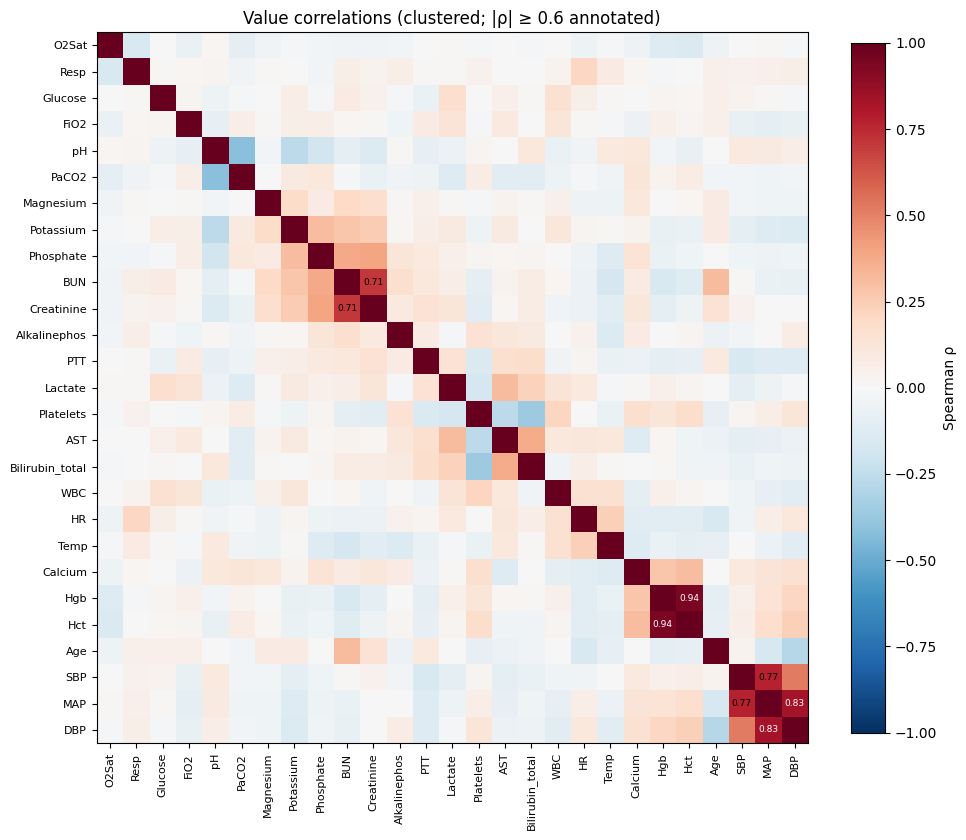

In [26]:
# Part 2-6 : 상관관계와 중복 변수: 같은 정보를 두 번 넣고 있지는 않은가?
# (1) 값의 상관: 정제 + forward fill 값, Spearman(순위 기반 → 비선형·이상치에 강함)
#     행이 130만 개라 환자 단위로 표본 추출(같은 환자의 반복 행이 상관을 부풀리지 않게 환자당 최대 24행)
# (2) 측정의 동시성: 두 검사가 '같은 시간에 함께' 측정되는 비율 (Jaccard) → 측정 패턴 특징을 묶을 근거
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

if 'clean_df' not in globals():
    clean_df, _ = apply_cleaning(eda_df)
excluded = set(config['excluded_features'])
CORR_VARS = [v for v in ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp',
                         'BUN', 'Creatinine', 'Glucose', 'Potassium', 'Magnesium', 'Phosphate', 'Calcium',
                         'Lactate', 'AST', 'Alkalinephos', 'Bilirubin_total',
                         'WBC', 'Hgb', 'Hct', 'Platelets', 'PTT', 'FiO2', 'pH', 'PaCO2', 'Age']
             if v not in excluded]

ffc = clean_df[['Patient_ID'] + CORR_VARS].copy()
ffc[CORR_VARS] = ffc.groupby('Patient_ID')[CORR_VARS].ffill()
rnd = pd.Series(np.random.default_rng(42).random(len(ffc)), index=ffc.index)
samp = ffc[rnd.groupby(ffc['Patient_ID']).rank(method='first') <= 24]      # 환자당 무작위 최대 24행
rho = samp[CORR_VARS].corr(method='spearman', min_periods=1000)
print(f'[표본] 환자 {samp.Patient_ID.nunique():,}명, {len(samp):,}행')

# 강한 상관 쌍
pairs = (rho.where(np.triu(np.ones(rho.shape, dtype=bool), k=1)).stack()
         .rename('rho').reset_index().rename(columns={'level_0': 'var1', 'level_1': 'var2'}))
pairs['abs'] = pairs['rho'].abs()
strong = pairs[pairs['abs'] >= 0.6].sort_values('abs', ascending=False)
print('\n[|Spearman ρ| ≥ 0.6 인 변수 쌍]')
print(strong[['var1', 'var2', 'rho']].round(3).to_string(index=False))

# 쌍마다 어느 쪽을 남길지: 2-4의 단독 판별력(strength)과 관측률(coverage)을 같이 보여줌
if 'uni' in globals():
    for _, r in strong[strong['abs'] >= 0.8].iterrows():
        a, b = r['var1'], r['var2']
        sa, sb = uni.loc[a, 'strength'], uni.loc[b, 'strength']
        ca, cb = uni.loc[a, 'coverage_%'], uni.loc[b, 'coverage_%']
        print(f"  {a:>10s} (strength {sa:.3f}, coverage {ca:.0f}%)  vs  {b:<10s} (strength {sb:.3f}, coverage {cb:.0f}%)")

# 측정 동시성 (Jaccard: 둘 중 하나라도 측정된 시간 중 둘 다 측정된 비율)
MEAS_GROUPS = {
    'liver panel': ['AST', 'Alkalinephos', 'Bilirubin_total'],
    'blood gas': ['pH', 'PaCO2', 'FiO2'],
    'CBC': ['WBC', 'Hgb', 'Hct', 'Platelets'],
    'chemistry': ['BUN', 'Creatinine', 'Potassium', 'Glucose'],
    'lactate vs gas': ['Lactate', 'pH'],
}
meas = clean_df[list(dict.fromkeys(v for g in MEAS_GROUPS.values() for v in g))].notna()   # 중복 열 제거


def jaccard(a: str, b: str) -> float:
    """Share of hours where both are measured among hours where either is."""
    both = (meas[a] & meas[b]).sum()
    either = (meas[a] | meas[b]).sum()
    return both / either if either else np.nan


print('\n[측정 동시성 (Jaccard)]  1에 가까울수록 같은 시간에 함께 측정됨')
for gname, vs in MEAS_GROUPS.items():
    vals = [f'{a}-{b}: {jaccard(a, b):.2f}' for i, a in enumerate(vs) for b in vs[i + 1:]]
    print(f'  {gname:15s}', ' | '.join(vals))

# 그래프: 계층 군집 순서로 정렬한 |ρ| 히트맵
dist = 1 - rho.abs().fillna(0).values
np.fill_diagonal(dist, 0)
order = leaves_list(linkage(squareform(dist, checks=False), method='average'))
r_ord = rho.iloc[order, order]
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(r_ord.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(r_ord)), r_ord.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(r_ord)), r_ord.index, fontsize=8)
for i in range(len(r_ord)):
    for j in range(len(r_ord)):
        v = r_ord.values[i, j]
        if i != j and abs(v) >= 0.6:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6.5,
                    color='white' if abs(v) > 0.8 else 'black')
plt.colorbar(im, ax=ax, fraction=0.04, label='Spearman ρ')
ax.set_title('Value correlations (clustered; |ρ| ≥ 0.6 annotated)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p2_redundancy.png', dpi=150)
plt.show()

1. 중복이 생각보다 적다.
26개 변수 중 강한 상관(|ρ| ≥ 0.8)은 두 쌍뿐이다. 대부분의 변수는 서로 다른 정보를 담고 있다. 그래서 window 통계로 특징을 늘려도 다중공선성 문제는 크지 않을 것으로 보인다.

2. 남길 변수를 정한 기준 (|ρ| ≥ 0.8이면 하나만 남김)

Hgb를 남기고 Hct는 제외. 판별력(0.542 대 0.539)과 관측률(78% 대 80%)이 거의 같아서 어느 쪽이든 괜찮다. Hgb가 임상에서 더 흔히 쓰이는 지표라 Hgb를 골랐음.
MAP를 남기고 DBP는 제외. MAP가 판별력(0.561 대 0.549)과 관측률(97% 대 79%) 모두 높고, SOFA 심혈관 항목의 기준 변수이다. 게다가 DBP는 Part 1에서 A 환자 36%가 한 번도 측정되지 않은 병원 고유 결측 변수였으니.
SBP와 MAP는 둘 다 유지. 상관이 0.77로 기준 아래이고, SBP는 qSOFA 기준 변수(≤ 100)라서 빠지면 안 된다.
BUN과 Creatinine도 둘 다 유지. BUN은 검사값 중 단독 판별력이 가장 높고(0.584), Creatinine은 SOFA 신장 항목의 기준 변수이니. 두 값의 비율(BUN/Creatinine)은 임상적으로 의미 있는 지표라 추가 특징으로 고려해볼 수 있다.

3. 간 기능 검사는 하나의 측정 indicator로 묶어도 된다.

AST, ALP, Bilirubin이 87-97%의 확률로 같은 시간에 측정된다. 2-3에서 "같이 처방되니까 묶자"고 제안했던 게 데이터로 확인됐다고 보면 된다.

4. 앞에서 가정을 하나 정정한다. FiO2는 혈액가스 측정을 대신할 수 없다.

2-3에서 “pH와 PaCO2 indicator는 차단하되, 같은 혈액가스 정보는 FiO2 indicator가 대신 담을 수 있다”고 했다.
그런데 pH와 FiO2가 같이 측정되는 비율은 0.28뿐이다. FiO2는 혈액가스 검사 결과가 아니라 인공호흡기 설정값이라 따로 기록되는 걸로 보아야 한다.
그래서 FiO2 indicator의 의미는 ”산소 치료나 인공호흡 중"에 가깝다고 해석해야 한다. 혈액가스 측정 정보는 pH/PaCO2 indicator 차단으로 그냥 잃게 되는 거고, 이 트레이드오프를 리포트에 남겨야 한다.

5. Lactate는 혈액가스와 별개로 다뤄야 한다.
Lactate와 pH의 측정 동시성이 0.36이다. 병원에 따라 Lactate를 혈액가스와 함께 재기도 하지만, 이 데이터에서는 대부분 따로 측정된다. 그래서 Lactate 측정 indicator는 독립적으로 유지하는 게 맞다.

[SOFA 항목별 상태 (행 비율 %)]  OK: 24h 안에 측정 / STALE: 24h 넘음 / NEVER: 아직 측정 전
                      OK  STALE  NEVER
component      set                    
coagulation    A    80.7    1.2   18.1
               B    70.9    2.4   26.7
liver          A    18.4    5.5   76.0
               B    28.0    8.5   63.4
renal          A    81.3    0.9   17.8
               B    73.0    1.8   25.1
cardiovascular A    98.1    0.1    1.8
               B    96.2    0.0    3.8
  respiratory, cns: 데이터셋에 변수 없음 → 모든 행 계산 불가

[행별 계산 가능한 SOFA 항목 수 (최대 4, 호흡·신경은 항상 불가) — 행 비율 %]
n_available    0     1    2     3     4
set                                    
A            1.8  14.7  4.6  61.0  17.9
B            3.4  21.5  5.5  42.7  26.8

[입실 후 시간별 항목 계산 가능 비율 (%)]
           sofa_coagulation  sofa_liver  sofa_renal  sofa_cardiovascular
history_h                                                               
1                       6.6         0.8         6.2                 20.8
3                      27.1       

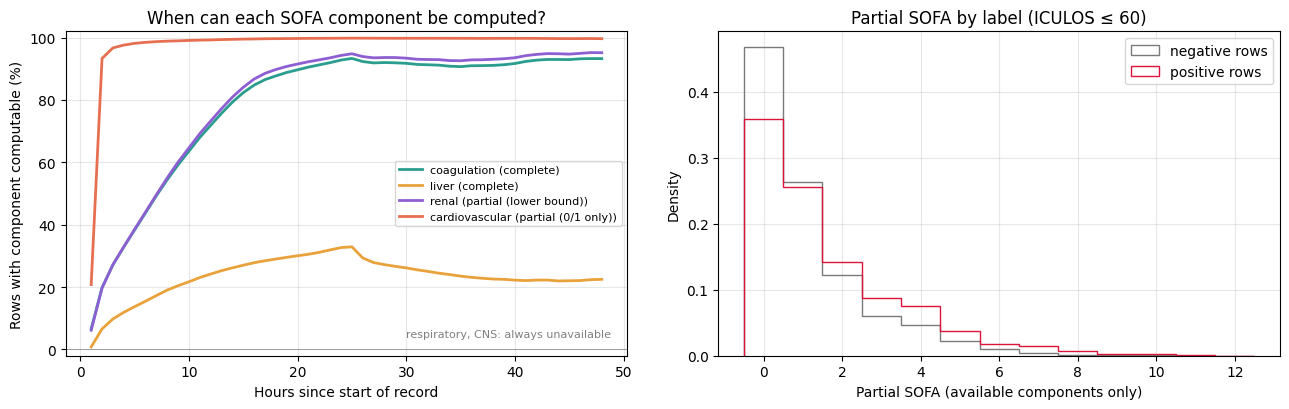

In [27]:
# Part 2-7 : SOFA·qSOFA 변수의 시간별 가용성: 언제부터, 몇 개 항목을 계산할 수 있는가
# 규칙 (기준 2, 5 반영)
#  - 각 항목은 '최근 24시간 안에 측정된 값'이 있을 때만 계산 (과거 값만 사용)
#  - 상태 3가지: OK(24h 안에 측정) / STALE(측정한 적은 있으나 24h 넘음) / NEVER(아직 한 번도 측정 안 됨)
#  - 데이터셋에 변수가 없는 항목(호흡: PaO2, 신경: GCS)은 항상 '계산 불가'
#  - 부분 항목: 신장(소변량 없음 → Creatinine만, 하한값), 심혈관(승압제 없음 → MAP<70 1점만)
VALID_H = 24

if 'clean_df' not in globals():
    clean_df, _ = apply_cleaning(eda_df)
sf = clean_df[['Patient_ID', 'set', 'ICULOS', 'SepsisLabel',
               'Platelets', 'Bilirubin_total', 'Creatinine', 'MAP', 'Resp', 'SBP']].copy()
gsf = sf.groupby('Patient_ID')
sf['history_h'] = sf['ICULOS'] - gsf['ICULOS'].transform('min') + 1


def latest_valid(df: pd.DataFrame, var: str) -> tuple:
    """Return (value within last VALID_H hours or NaN, state label) using past data only."""
    last_t = df['ICULOS'].where(df[var].notna()).groupby(df['Patient_ID']).ffill()
    val = df[var].groupby(df['Patient_ID']).ffill()
    age = df['ICULOS'] - last_t
    state = np.select([last_t.isna(), age >= VALID_H], ['NEVER', 'STALE'], 'OK')
    return val.where(state == 'OK'), pd.Series(state, index=df.index)


def score_platelets(x):  # 응고
    return pd.cut(x, [-np.inf, 20, 50, 100, 150, np.inf], right=False, labels=[4, 3, 2, 1, 0]).astype(float)

def score_bilirubin(x):  # 간
    return pd.cut(x, [-np.inf, 1.2, 2.0, 6.0, 12.0, np.inf], right=False, labels=[0, 1, 2, 3, 4]).astype(float)

def score_creatinine(x):  # 신장 (Creatinine 기준만 → 하한값)
    return pd.cut(x, [-np.inf, 1.2, 2.0, 3.5, 5.0, np.inf], right=False, labels=[0, 1, 2, 3, 4]).astype(float)

def score_map(x):  # 심혈관 (MAP<70 → 1점만, 승압제 정보 없음)
    return np.where(x.isna(), np.nan, (x < 70).astype(float))


COMPONENTS = {  # 항목: (변수, 점수함수, 구분)
    'coagulation': ('Platelets', score_platelets, 'complete'),
    'liver': ('Bilirubin_total', score_bilirubin, 'complete'),
    'renal': ('Creatinine', score_creatinine, 'partial (lower bound)'),
    'cardiovascular': ('MAP', score_map, 'partial (0/1 only)'),
}
for comp, (var, fn, _) in COMPONENTS.items():
    val, state = latest_valid(sf, var)
    sf[f'{comp}_state'] = state
    sf[f'sofa_{comp}'] = fn(val)
sf['sofa_respiratory'] = np.nan   # PaO2 없음 → 계산 불가
sf['sofa_cns'] = np.nan           # GCS 없음 → 계산 불가

# qSOFA (부분: 의식 변화는 GCS가 없어 계산 불가 → 3개 중 2개)
resp_v, resp_s = latest_valid(sf, 'Resp')
sbp_v, sbp_s = latest_valid(sf, 'SBP')
sf['qsofa_resp'] = np.where(resp_v.isna(), np.nan, (resp_v >= 22).astype(float))
sf['qsofa_sbp'] = np.where(sbp_v.isna(), np.nan, (sbp_v <= 100).astype(float))

# (1) 항목별 상태 분포 (행 단위, set별)
state_cols = [f'{c}_state' for c in COMPONENTS]
st = pd.concat({c.replace('_state', ''): sf.groupby('set')[c].value_counts(normalize=True).mul(100).unstack()
                for c in state_cols}, names=['component']).round(1)[['OK', 'STALE', 'NEVER']]
print('[SOFA 항목별 상태 (행 비율 %)]  OK: 24h 안에 측정 / STALE: 24h 넘음 / NEVER: 아직 측정 전')
print(st)
print('  respiratory, cns: 데이터셋에 변수 없음 → 모든 행 계산 불가')

# (2) 계산 가능한 항목 수 (6개 중)
sofa_cols = ['sofa_respiratory', 'sofa_coagulation', 'sofa_liver', 'sofa_cardiovascular', 'sofa_cns', 'sofa_renal']
sf['n_available'] = sf[sofa_cols].notna().sum(axis=1)
print('\n[행별 계산 가능한 SOFA 항목 수 (최대 4, 호흡·신경은 항상 불가) — 행 비율 %]')
print(sf.groupby('set')['n_available'].value_counts(normalize=True).mul(100).unstack().round(1))

# (3) 입실 후 시간에 따른 가용성 곡선
avail = sf[sf['history_h'] <= 48].groupby('history_h')[[f'sofa_{c}' for c in COMPONENTS]].apply(
    lambda d: d.notna().mean() * 100)
print('\n[입실 후 시간별 항목 계산 가능 비율 (%)]')
print(avail.loc[[1, 3, 6, 12, 24, 48]].round(1))

# (4) 부분 SOFA 총점과 변화량 (총점 필드는 '계산 불가', 대신 가용 항목 합 = 부분 점수, 하한값)
#     변화량 주의: 총점끼리 빼면, 새로 측정된 항목이 총점에 '추가'되는 순간 점수가 뛰어오름 (가용성 점프)
#     → 항목별로 (현재 점수 - 과거 24h 최솟값)을 구한 뒤 합산: 같은 항목끼리만 비교
sf['sofa_partial'] = sf[sofa_cols].sum(axis=1, min_count=1)
naive_base = (sf.groupby('Patient_ID')['sofa_partial']
              .rolling(VALID_H, min_periods=1).min().reset_index(level=0, drop=True))
sf['sofa_delta_naive'] = sf['sofa_partial'] - naive_base                       # 비교용 (잘못된 방식)
comp_deltas = []
for c in COMPONENTS:
    base_c = (sf.groupby('Patient_ID')[f'sofa_{c}']
              .rolling(VALID_H, min_periods=1).min().reset_index(level=0, drop=True))  # 과거 24h 최솟값
    comp_deltas.append(sf[f'sofa_{c}'] - base_c)
sf['sofa_partial_delta'] = pd.concat(comp_deltas, axis=1).sum(axis=1, min_count=1)
sf['qsofa_partial'] = sf[['qsofa_resp', 'qsofa_sbp']].sum(axis=1, min_count=1)

le60s = sf['ICULOS'] <= 60
print('\n[판별력 (ICULOS ≤ 60, 방향 무관 AUROC)]')
for col in ['sofa_partial', 'sofa_delta_naive', 'sofa_partial_delta', 'qsofa_partial'] + [f'sofa_{c}' for c in COMPONENTS]:
    ok = le60s & sf[col].notna()
    a = roc_auc_score(sf.loc[ok, 'SepsisLabel'], sf.loc[ok, col])
    print(f'  {col:22s} {max(a, 1 - a):.3f}  (계산 가능 행 {100 * ok.sum() / le60s.sum():.1f}%)')

# (5) 명세의 'SOFA +2' 라벨과 공식 라벨 비교 (보조 분석, 기준 3: 공식 라벨은 그대로 사용)
rows_ev = {}
for name, col in [('naive (total - baseline)', 'sofa_delta_naive'), ('per-component (사용)', 'sofa_partial_delta')]:
    ev = (sf[col] >= 2)
    pt_ev = sf[le60s].assign(ev=ev[le60s]).groupby('Patient_ID').agg(sepsis=('SepsisLabel', 'max'), ev=('ev', 'max'))
    r = pt_ev.groupby('sepsis')['ev'].mean().mul(100)
    rows_ev[name] = {'non_sepsis_with_+2_%': r.get(0), 'sepsis_with_+2_%': r.get(1)}
print('\n[부분 SOFA +2 이벤트가 있는 환자 비율 (ICULOS ≤ 60)]')
print(pd.DataFrame(rows_ev).T.round(1))

# 패혈증 환자: +2 이벤트가 라벨 시작(T)보다 먼저 오는가
first_ev = sf[sf['sofa_partial_delta'] >= 2].groupby('Patient_ID')['ICULOS'].min()
t_on = sf[sf['SepsisLabel'] == 1].groupby('Patient_ID')['ICULOS'].min()
lag = (first_ev.reindex(t_on.index) - t_on).dropna()
print(f'\n[패혈증 환자: 첫 +2 이벤트 시점 - 라벨 시작 시점 (h)]  이벤트 있는 환자 {len(lag):,}/{len(t_on):,}명')
print('  중앙값', lag.median(), '| 라벨 시작 전(<0) 비율', round(100 * (lag < 0).mean(), 1), '%',
      '| t_sepsis(+6) 이후 비율', round(100 * (lag > 6).mean(), 1), '%')

# (6) 그래프: (왼쪽) 입실 후 시간별 가용성, (오른쪽) 부분 SOFA 분포 (양성/음성 행)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ccol = {'coagulation': '#2a9d8f', 'liver': '#e9a23b', 'renal': '#8d5fd3', 'cardiovascular': '#e76f51'}
for c in COMPONENTS:
    ax.plot(avail.index, avail[f'sofa_{c}'], color=ccol[c], lw=2, label=f'{c} ({COMPONENTS[c][2]})')
ax.axhline(0, color='gray', lw=0.5)
ax.text(30, 4, 'respiratory, CNS: always unavailable', color='gray', fontsize=8)
ax.set_xlabel('Hours since start of record')
ax.set_ylabel('Rows with component computable (%)')
ax.set_ylim(-2, 102)
ax.set_title('When can each SOFA component be computed?')
ax.legend(fontsize=8, loc='center right')
ax.grid(alpha=0.3)

ax = axes[1]
d = sf[le60s & sf['sofa_partial'].notna()]
bins_s = np.arange(-0.5, d['sofa_partial'].max() + 1.5, 1)
for lab, col, name in [(0, '#7a7a7a', 'negative rows'), (1, 'crimson', 'positive rows')]:
    ax.hist(d.loc[d['SepsisLabel'] == lab, 'sofa_partial'], bins=bins_s, density=True,
            histtype='step', lw=2, color=col, label=name)
ax.set_xlabel('Partial SOFA (available components only)')
ax.set_ylabel('Density')
ax.set_title('Partial SOFA by label (ICULOS ≤ 60)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/p2_sofa_availability.png', dpi=150)
plt.show()

1. 입실 직후에는 SOFA를 거의 계산할 수 없다.

입실 6시간째까지 응고와 신장 항목은 44%만 계산된다. 24시간이 지나야 90%를 넘는다. 혈액검사를 하루 한 번 정도 하기 때문인데,
2-1에서 패혈증 환자의 23-28%는 라벨이 시작되기 전 기록이 6시간 미만이었다. 이 환자들에게는 SOFA가 거의 측정 전 상태라서, 조기 경보에 SOFA만 쓰면 이 환자들을 놓치게 된다.
그래서 SOFA는 모델의 핵심 입력이라기보다 대시보드에서 의료진에게 보여주는 설명 정보로 쓰는 게 맞다. 예측은 매시간 측정되는 활력징후 중심의 ML 모델이 한다.

2. 간 항목은 24시간이 지나면 오히려 줄어든다.

그림에서 간 항목 곡선이 25시간에 정점을 찍고 떨어진다. 입실할 때 한 번 측정하고 다시 안 재는 경우가 많아서, 24시간이 지나면 STALE로 바뀌는 것인데, 유효 기간 규칙이 의도대로 작동한다는 확인이기도 하다.

3. 부분 SOFA의 판별력은 단일 활력징후 수준이다.

부분 SOFA는 0.577로, HR(0.603)이나 Temp(0.599)보다 낮다. 6개 항목 중 4개만, 그것도 2개는 일부만 계산할 수 있으니 당연한 결과이다.
부분 qSOFA(0.574)도 비슷. 의식 변화 항목이 빠진 영향.
그래도 오른쪽 그림처럼 양성 행이 높은 점수 쪽에 더 많아서 정보는 있다. 모델 특징으로 넣을 가치는 있지만, 단독으로는 약하다고 이해하자.

4. 명세의 “SOFA +2 라벨링”은 이 데이터로는 쓸 수 없다. 기준 3번의 가장 강한 근거.

올바른 방식(항목별 변화량)으로 계산해도 +2 이벤트가 있는 비율이 비패혈증 12.2%, 패혈증 15.3%로 거의 같다. 이걸 라벨로 쓰면 패혈증과 비패혈증을 구분하지 못한다.
전체 패혈증 환자 2,492명 중 +2 이벤트가 있는 환자는 617명(24.8%)뿐이고, 그 시점도 라벨 시작보다 중앙값 21시간 앞이라 패혈증 발병과 시점이 맞지 않는다.
원인은 두 가지인데, 공식 라벨은 감염 의심(항생제, 혈액배양)이 함께 있어야 하는데 이 정보가 데이터에 없다. 그리고 SOFA 6개 항목 중 2개는 아예 계산할 수 없도 없다.
그래서 리포트에는 이렇게 쓰자. "명세의 SOFA +2 라벨링을 구현해 공식 라벨과 비교했으나, 일치도가 낮아(비패혈증 12.2% 대 패혈증 15.3%) 학습 타깃으로는 공식 SepsisLabel을 사용했다."

5. 가용성 점프는 모델 특징에서도 조심한다.

부분 SOFA 총점을 그대로 특징으로 넣으면, "검사를 새로 했다"는 사실이 점수 상승처럼 보인다. 그래서 항목별 점수와 항목별 상태(OK/STALE/NEVER)를 따로 특징으로 넣는 게 더 정확함.